# NexusTrader — Frozen Ablation Analysis Notebook

All data loaded from pre-scored frozen CSVs. No LLM calls or re-scoring required.

**Stages covered:** A (baseline) → B (specialist extraction) → B+ (risk gate) → C (risk debate, negative) → D (memory)
**Eval set:** n=385, k=10 trading days, 5 tickers × 77 dates
**Key metric:** `dir_acc_ex_hold_%` — directional accuracy on committed BUY/SELL calls only

## 0) Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1) Config & File Paths

In [41]:
BASE_DIR     = Path(".")   # run notebook from nexustrader/experiments/
REPORTS_DIR = BASE_DIR / "results" / "analysis_reports"
CHART_DIR   = BASE_DIR / "results" / "charts_analysis"
CHART_DIR.mkdir(parents=True, exist_ok=True)

STAGE_DIRS = {
    "Stage A":  REPORTS_DIR / "eval385_stageA_new_v2",
    "Stage B":  REPORTS_DIR / "eval385_stageB_v3",
    "Stage B+": REPORTS_DIR / "eval385_stageB_plus_v3",
    "Stage C":  REPORTS_DIR / "eval385_stageC_PAID_V2_R1_final",
    "Stage D":  REPORTS_DIR / "eval385_stageD_llm_lessons_v1",
}

STAGE_ORDER = ["Stage A", "Stage B", "Stage B+", "Stage C", "Stage D"]

STAGE_COLORS = {
    "Stage A":  "#4C72B0",   # blue
    "Stage B":  "#55A868",   # green
    "Stage B+": "#C44E52",   # red
    "Stage C":  "#8172B2",   # purple — negative result
    "Stage D":  "#CCB974",   # gold
}

HOLD_EPSILON_BASE = 0.02                             # epsilon used in all frozen scorings
EPSILON_SWEEP     = [0.01, 0.02, 0.03, 0.05, 0.08]  # sweep for HOLD quality analysis

print("REPORTS_DIR:", REPORTS_DIR.resolve())
print("CHART_DIR:  ", CHART_DIR.resolve())

REPORTS_DIR: C:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\analysis_reports
CHART_DIR:   C:\Users\Madi\Documents\season_25-26\academic_25-26\FYP_multi_agent_trading\nexustrader\experiments\results\charts_analysis


## 2) Load Frozen CSVs

In [42]:
# ── Agent rows per stage ──────────────────────────────────────────────────
agent_dfs   = {}
summary_dfs = {}

for stage in STAGE_ORDER:
    d = STAGE_DIRS[stage]
    df = pd.read_csv(d / "agent_rows_scored.csv")
    df["stage"] = stage
    agent_dfs[stage]   = df
    summary_dfs[stage] = pd.read_csv(d / "agent_summary.csv")

# ── Baselines ─────────────────────────────────────────────────────────────────
# All stages share the same static baselines; Stage A copy is authoritative
baselines = pd.read_csv(STAGE_DIRS["Stage A"] / "baseline_rows_scored.csv")

# ── Matched-rows & flip files ─────────────────────────────────────────────────
a_vs_b_matched    = pd.read_csv(STAGE_DIRS["Stage B"]  / "stageA_stageB_date_matched_rows.csv")
b_vs_bplus_matched = pd.read_csv(STAGE_DIRS["Stage B+"] / "Stage_B_Stage_Bplus_date_matched_rows.csv")

a_vs_b_flips      = pd.read_csv(STAGE_DIRS["Stage B"]  / "stageA_stageB_flips_all.csv")
b_vs_bplus_flips  = pd.read_csv(STAGE_DIRS["Stage B+"] / "Stage_B_Stage_Bplus_flips_all.csv")

stageC_audit  = pd.read_csv(STAGE_DIRS["Stage C"] / "summary_stageC_flip_audit.csv")
stageC_jdist  = pd.read_csv(STAGE_DIRS["Stage C"] / "summary_stageC_judgment_distribution.csv")
stageC_health = pd.read_csv(STAGE_DIRS["Stage C"] / "summary_stageC_health_flags.csv")

# ── Combined long-format DataFrame ───────────────────────────────────────────
all_agent = pd.concat(agent_dfs.values(), ignore_index=True)
all_agent["stage"] = pd.Categorical(all_agent["stage"], categories=STAGE_ORDER, ordered=True)

print("Loaded agent rows per stage:")
for stage in STAGE_ORDER:
    df = agent_dfs[stage]
    h  = (df["action"] == "HOLD").sum()
    print(f"  {stage:<10}: {len(df)} rows | HOLDs={h} ({h/len(df)*100:.1f}%)")
print(f"\nBaselines: {len(baselines)} rows | strategies: {baselines['strategy'].unique().tolist()}")

Loaded agent rows per stage:
  Stage A   : 385 rows | HOLDs=5 (1.3%)
  Stage B   : 385 rows | HOLDs=83 (21.6%)
  Stage B+  : 385 rows | HOLDs=86 (22.3%)
  Stage C   : 385 rows | HOLDs=117 (30.4%)
  Stage D   : 385 rows | HOLDs=83 (21.6%)

Baselines: 1540 rows | strategies: ['buy_hold', 'sma_crossover', 'rsi_14', 'random_uniform']


## 3) All-Stage Summary Metrics

In [11]:
# Pull metrics from frozen summary CSVs
COLS = {
    "dir_acc":   "dir_acc_ex_hold_%",
    "hold_rate": "hold_rate_%",
    "hold_acc":  "hold_acc_%",
    "buy_acc":   "buy_acc_%",
    "sell_acc":  "sell_acc_%",
    "dir_n":     "dir_acc_ex_hold_n",
    "hold_n":    "hold_n",
    "buy_n":     "buy_n",
    "sell_n":    "sell_n",
    "n":         "n",
    "mean_excess": "mean_excess_vs_bh_%",
}

summ_rows = []
for stage in STAGE_ORDER:
    row = summary_dfs[stage].iloc[0]
    r = {k: float(row[v]) if v in row else float("nan") for k, v in COLS.items()}
    r["stage"] = stage
    summ_rows.append(r)

summ = pd.DataFrame(summ_rows).set_index("stage")

display_cols = ["dir_acc", "hold_rate", "hold_acc", "buy_acc", "sell_acc", "dir_n", "hold_n", "mean_excess"]
print("=== Frozen Summary Metrics (n=385, k=10) ===")
print(summ[display_cols].round(2).to_string())

=== Frozen Summary Metrics (n=385, k=10) ===
          dir_acc  hold_rate  hold_acc  buy_acc  sell_acc  dir_n  hold_n  mean_excess
stage                                                                                
Stage A     55.00       1.30     60.00    61.25     44.29  380.0     5.0        -0.84
Stage B     54.30      21.56     62.65    60.71     46.27  302.0    83.0        -1.01
Stage B+    54.52      22.34     73.26    61.82     45.52  299.0    86.0        -1.10
Stage C     51.87      30.39     41.88    58.62     43.90  268.0   117.0        -1.32
Stage D     54.30      21.56     39.76    60.92     45.31  302.0    83.0        -1.11


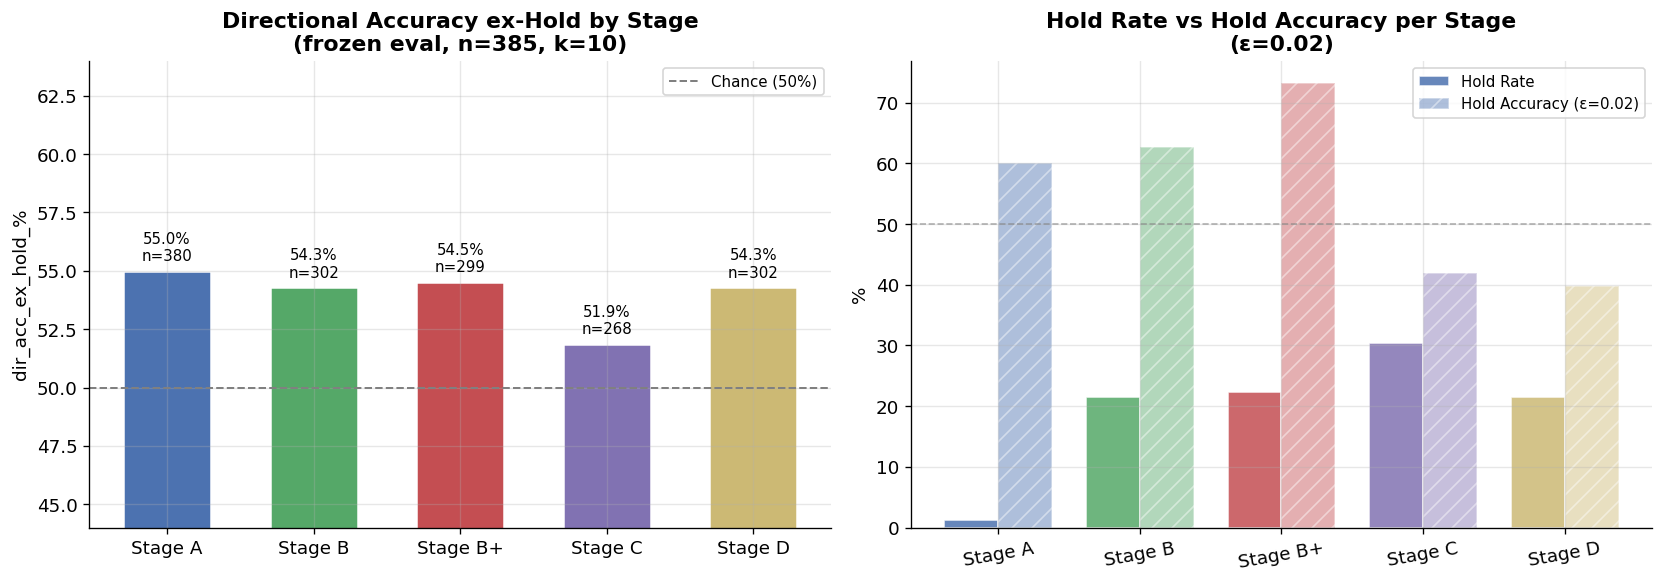

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: dir_acc_ex_hold ─────────────────────────────────────────────────
ax = axes[0]
colors = [STAGE_COLORS[s] for s in STAGE_ORDER]
bars = ax.bar(STAGE_ORDER, summ.loc[STAGE_ORDER, "dir_acc"],
              color=colors, edgecolor="white", linewidth=1.5, width=0.6)
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2, label="Chance (50%)")
for b, stage in zip(bars, STAGE_ORDER):
    row = summ.loc[stage]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
            f"{row['dir_acc']:.1f}%\nn={row['dir_n']:.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(44, 64)
ax.set_title("Directional Accuracy ex-Hold by Stage\n(frozen eval, n=385, k=10)", fontweight="bold")
ax.set_ylabel("dir_acc_ex_hold_%")
ax.legend(fontsize=9)

# ── Chart 2: hold_rate vs hold_acc ───────────────────────────────────────────
ax2 = axes[1]
x = np.arange(len(STAGE_ORDER))
w = 0.38
b1 = ax2.bar(x - w/2, summ.loc[STAGE_ORDER, "hold_rate"],  width=w, color=colors, alpha=0.85,
             label="Hold Rate", edgecolor="white")
b2 = ax2.bar(x + w/2, summ.loc[STAGE_ORDER, "hold_acc"],   width=w, color=colors, alpha=0.45,
             hatch="//", label="Hold Accuracy (ε=0.02)", edgecolor="white")
ax2.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(STAGE_ORDER, rotation=10)
ax2.set_title("Hold Rate vs Hold Accuracy per Stage\n(ε=0.02)", fontweight="bold")
ax2.set_ylabel("%")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "01_all_stages_overview.png", bbox_inches="tight")
plt.show()

## 4) Baseline Comparisons

Four static baselines (computed once against the same eval rows):
- **buy_hold** — always BUY
- **sma_crossover** — signal from 10/30-day MA cross
- **rsi_14** — RSI < 30 → BUY, > 70 → SELL, else HOLD-equivalent
- **random_uniform** — random BUY/SELL at equal probability

All baselines are committed calls (no HOLD), so their `dir_acc = overall_acc`.

In [13]:
bl_summ = (
    baselines.groupby("strategy")
    .agg(n=("correct", "count"), overall_acc=("correct", lambda x: round(x.mean() * 100, 2)))
    .reset_index()
).sort_values("overall_acc", ascending=False)

print("Baseline accuracy (all committed, k=10, n per strategy):")
print(bl_summ.to_string(index=False))

Baseline accuracy (all committed, k=10, n per strategy):
      strategy   n  overall_acc
      buy_hold 385        59.22
 sma_crossover 385        51.43
random_uniform 385        40.26
        rsi_14 385        34.29


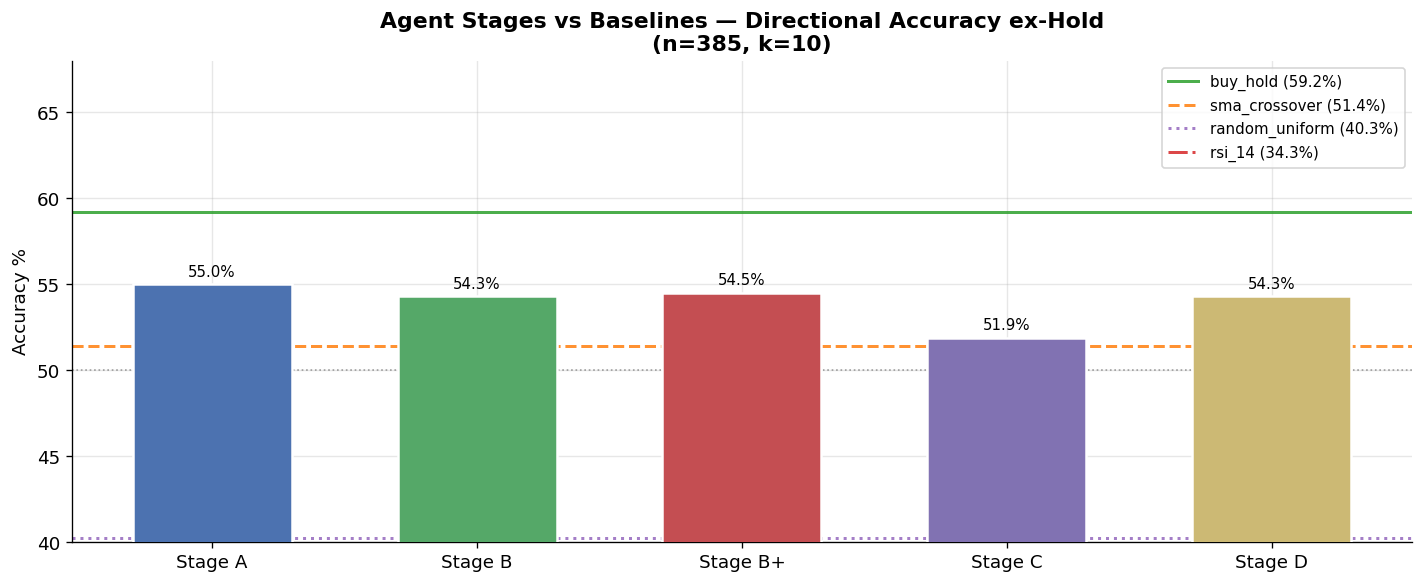

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

# Agent stages bars
stage_accs = summ.loc[STAGE_ORDER, "dir_acc"].values
bars = ax.bar(STAGE_ORDER, stage_accs,
              color=[STAGE_COLORS[s] for s in STAGE_ORDER],
              width=0.6, edgecolor="white", linewidth=1.5, zorder=3)
for b, val in zip(bars, stage_accs):
    ax.text(b.get_x() + b.get_width() / 2, val + 0.3, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=9)

# Baseline reference lines
bl_style = {
    "buy_hold":       ("#2ca02c", "-"),
    "sma_crossover":  ("#ff7f0e", "--"),
    "rsi_14":         ("#d62728", "-."),
    "random_uniform": ("#9467bd", ":"),
}
for _, row in bl_summ.iterrows():
    strat = row["strategy"]
    clr, ls = bl_style.get(strat, ("gray", "--"))
    ax.axhline(row["overall_acc"], color=clr, linestyle=ls, linewidth=1.8, alpha=0.85,
               label=f"{strat} ({row['overall_acc']:.1f}%)")

ax.axhline(50, color="black", linestyle=":", linewidth=1, alpha=0.35)
ax.set_ylim(40, 68)
ax.set_title("Agent Stages vs Baselines — Directional Accuracy ex-Hold\n(n=385, k=10)", fontweight="bold")
ax.set_ylabel("Accuracy %")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_baselines_vs_agents.png", bbox_inches="tight")
plt.show()

## 5) Variable Hold Epsilon Analysis

The frozen scoring used `HOLD_EPSILON = 0.02` (|k_return| < 2% over k=10 days = "stock barely moved, HOLD correct").

This section re-scores hold quality across different epsilon values to answer:
- Were the stages' HOLD calls _genuinely_ low-volatility calls, or did they abstain on high-movers?
- At what epsilon does a stage's hold accuracy exceed chance?

> Note: `dir_acc_ex_hold` does **not** change with epsilon — it only affects how we evaluate HOLD rows.

In [15]:
def metrics_at_epsilon(df, epsilon):
    """Recompute HOLD quality at a given epsilon threshold."""
    hold_df   = df[df["action"] == "HOLD"]
    commit_df = df[df["action"] != "HOLD"]
    hold_acc = (hold_df["k_return"].abs() < epsilon).mean() * 100 if len(hold_df) > 0 else float("nan")
    dir_acc  = commit_df["correct"].mean() * 100 if len(commit_df) > 0 else float("nan")
    # How many committed rows SHOULD have been held at this epsilon
    missed_hold = int((commit_df["k_return"].abs() < epsilon).sum())
    return {
        "hold_acc":     hold_acc,
        "dir_acc":      dir_acc,
        "hold_rate":    len(hold_df) / len(df) * 100,
        "hold_n":       len(hold_df),
        "dir_n":        len(commit_df),
        "missed_holds": missed_hold,   # committed rows that moved < epsilon
    }

eps_rows = []
for eps in EPSILON_SWEEP:
    for stage in STAGE_ORDER:
        m = metrics_at_epsilon(agent_dfs[stage], eps)
        eps_rows.append({"stage": stage, "epsilon": eps, **m})

eps_df = pd.DataFrame(eps_rows)

print("=== Hold Accuracy (%) at Different Epsilons ===")
pivot = eps_df.pivot_table(index="stage", columns="epsilon", values="hold_acc")
print(pivot.reindex(STAGE_ORDER).round(1).to_string())

print("\n=== Missed HOLD Opportunities (committed rows with |k_return| < ε) ===")
pivot2 = eps_df.pivot_table(index="stage", columns="epsilon", values="missed_holds")
print(pivot2.reindex(STAGE_ORDER).to_string())

=== Hold Accuracy (%) at Different Epsilons ===
epsilon   0.01  0.02  0.03  0.05  0.08
stage                                 
Stage A    0.0  60.0  60.0  80.0  80.0
Stage B   12.0  27.7  39.8  62.7  85.5
Stage B+  17.4  36.0  52.3  73.3  87.2
Stage C   14.5  33.3  47.0  70.1  85.5
Stage D   12.0  28.9  49.4  73.5  88.0

=== Missed HOLD Opportunities (committed rows with |k_return| < ε) ===
epsilon   0.01   0.02   0.03   0.05   0.08
stage                                     
Stage A   64.0  118.0  184.0  258.0  326.0
Stage B   54.0   98.0  154.0  210.0  259.0
Stage B+  49.0   90.0  142.0  199.0  255.0
Stage C   47.0   82.0  132.0  180.0  230.0
Stage D   54.0   97.0  146.0  201.0  257.0


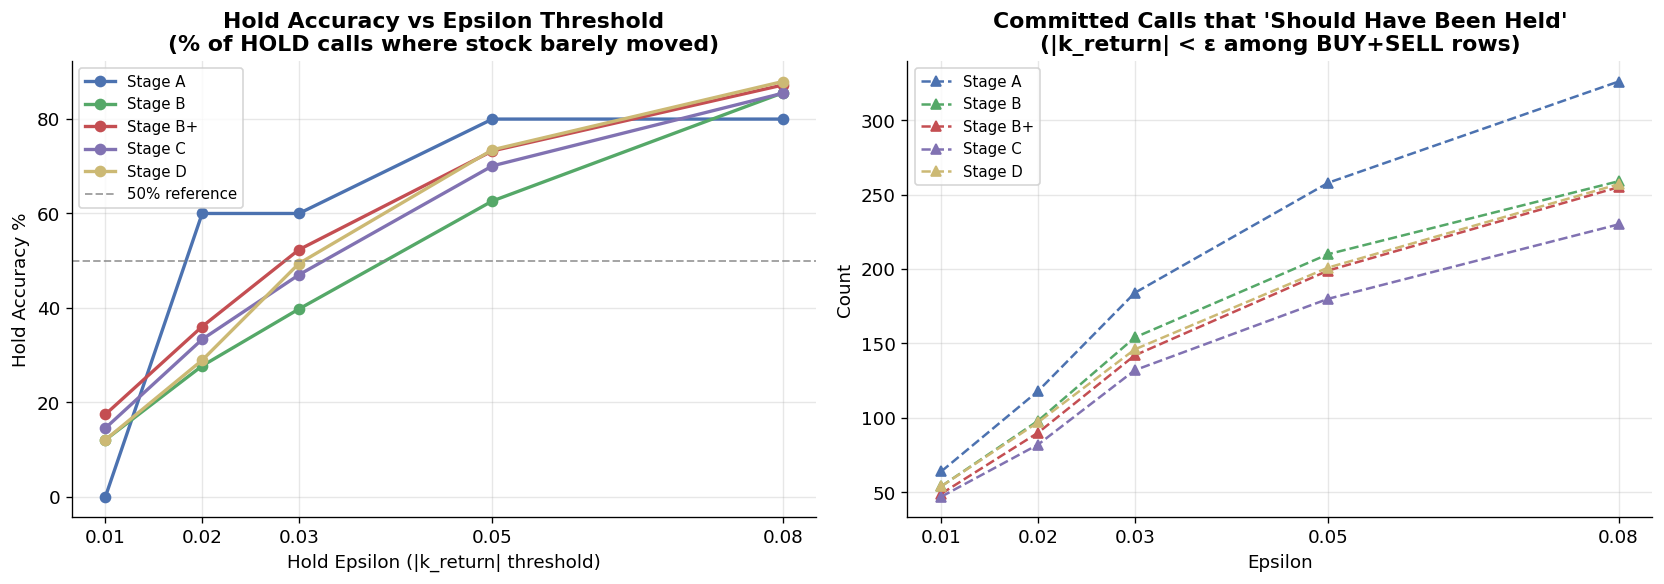

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Hold accuracy vs epsilon
ax1 = axes[0]
for stage in STAGE_ORDER:
    sub = eps_df[eps_df["stage"] == stage]
    ax1.plot(sub["epsilon"], sub["hold_acc"], marker="o", label=stage,
             color=STAGE_COLORS[stage], linewidth=2, markersize=6)
ax1.axhline(50, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label="50% reference")
ax1.set_xlabel("Hold Epsilon (|k_return| threshold)")
ax1.set_ylabel("Hold Accuracy %")
ax1.set_title("Hold Accuracy vs Epsilon Threshold\n(% of HOLD calls where stock barely moved)", fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_xticks(EPSILON_SWEEP)

# Chart 2: Missed holds (committed calls that moved < epsilon)
ax2 = axes[1]
for stage in STAGE_ORDER:
    sub = eps_df[eps_df["stage"] == stage]
    ax2.plot(sub["epsilon"], sub["missed_holds"], marker="^", linestyle="--", label=stage,
             color=STAGE_COLORS[stage], linewidth=1.5)
ax2.set_xlabel("Epsilon")
ax2.set_ylabel("Count")
ax2.set_title("Committed Calls that 'Should Have Been Held'\n(|k_return| < ε among BUY+SELL rows)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xticks(EPSILON_SWEEP)

plt.tight_layout()
plt.savefig(CHART_DIR / "03_epsilon_sweep.png", bbox_inches="tight")
plt.show()

## 6) Stage A → B: Specialist Extraction Impact

Stage B adds two specialist extractors (Upside Catalyst + Downside Risk analysts) whose highlights
the Manager reads before deciding. Stage A Manager reads the analyst reports directly.

Both stages use the **same frozen analyst reports** (cached from Stage A trace).
Disagreements between A and B are therefore attributable to: (1) the additional highlights, and
(2) downstream Manager non-determinism from running on a different day (2026-03-14 vs 2026-03-13).

The flip analysis measures: when Stage B *changed* Stage A's decision, was that change correct?

In [17]:
flip_rate = a_vs_b_matched["flipped"].mean() * 100
agree_rate = 100 - flip_rate

helped  = int(a_vs_b_flips["flip_helped"].sum())
hurt    = int(a_vs_b_flips["flip_hurt"].sum())
total_f = len(a_vs_b_flips)
neutral = total_f - helped - hurt

print(f"Stage A vs Stage B — {len(a_vs_b_matched)} matched rows")
print(f"  Agreement rate: {agree_rate:.1f}%  |  Flip rate: {flip_rate:.1f}%")
print(f"  Total flips:  {total_f}")
print(f"  Helped (A wrong → B right): {helped}")
print(f"  Hurt   (A right → B wrong): {hurt}")
print(f"  Neutral (both same outcome): {neutral}")
print(f"  Net quality:   {helped - hurt:+d}")

# Action distribution comparison
ab_melted = a_vs_b_matched.melt(
    id_vars=["ticker","simulated_date"],
    value_vars=["action_A", "action_B"], var_name="run", value_name="action"
)
action_dist_ab = ab_melted.groupby(["run","action"]).size().unstack(fill_value=0)
print("\nAction distribution:")
print(action_dist_ab.to_string())

Stage A vs Stage B — 385 matched rows
  Agreement rate: 79.0%  |  Flip rate: 21.0%
  Total flips:  81
  Helped (A wrong → B right): 12
  Hurt   (A right → B wrong): 31
  Neutral (both same outcome): 38
  Net quality:   -19

Action distribution:
action    BUY  HOLD  SELL
run                      
action_A  243     2   140
action_B  168    83   134


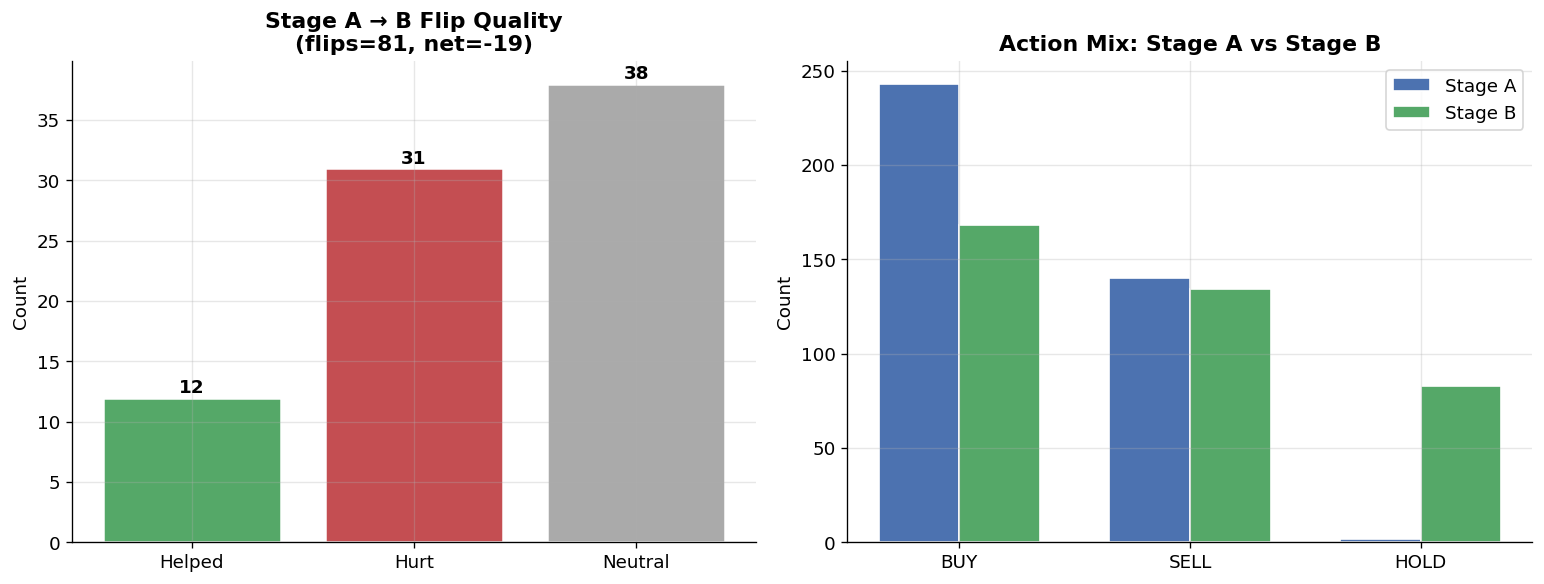

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Flip quality bar
ax1 = axes[0]
cats   = ["Helped", "Hurt", "Neutral"]
vals   = [helped, hurt, neutral]
clrs   = ["#55A868", "#C44E52", "#aaaaaa"]
bars   = ax1.bar(cats, vals, color=clrs, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.4, str(v), ha="center", fontweight="bold")
ax1.set_title(f"Stage A → B Flip Quality\n(flips={total_f}, net={helped-hurt:+d})", fontweight="bold")
ax1.set_ylabel("Count")

# Action distribution
ax2 = axes[1]
labels_act = [l for l in ["BUY", "SELL", "HOLD"] if l in action_dist_ab.columns]
x_pos  = np.arange(len(labels_act))
w      = 0.35
a_vals = [action_dist_ab.loc["action_A", l] if l in action_dist_ab.columns else 0 for l in labels_act]
b_vals = [action_dist_ab.loc["action_B", l] if l in action_dist_ab.columns else 0 for l in labels_act]
ax2.bar(x_pos - w/2, a_vals, width=w, label="Stage A", color=STAGE_COLORS["Stage A"], edgecolor="white")
ax2.bar(x_pos + w/2, b_vals, width=w, label="Stage B", color=STAGE_COLORS["Stage B"], edgecolor="white")
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels_act)
ax2.set_title("Action Mix: Stage A vs Stage B", fontweight="bold")
ax2.set_ylabel("Count"); ax2.legend()

plt.tight_layout()
plt.savefig(CHART_DIR / "04_a_vs_b_flips.png", bbox_inches="tight")
plt.show()

## 7) Stage B → B+: Single Risk Gate Impact

Stage B+ adds a single risk judge that can output CLEAR / REDUCE / BLOCK.
BLOCK converts a BUY/SELL to HOLD. REDUCE is a soft caution (no action change in these runs).

Upstream analyst reports and Stage A prior are identical to Stage B.
The Manager call is a **fresh LLM sample** (2026-03-18 vs 2026-03-14) — some disagreements
between B and B+ come from this Manager re-sampling, not from the risk gate directly.
The flip analysis characterises the overall decision quality change.

In [19]:
flip_rate_bb = b_vs_bplus_matched["flipped"].mean() * 100
agree_rate_bb = 100 - flip_rate_bb

# Column names in this file use "Stage B" and "Stage B+"
col_a = "action_Stage B"
col_b = "action_Stage B+"
helped_bb  = int(b_vs_bplus_flips["flip_helped"].sum())
hurt_bb    = int(b_vs_bplus_flips["flip_hurt"].sum())
total_f_bb = len(b_vs_bplus_flips)
neutral_bb = total_f_bb - helped_bb - hurt_bb

print(f"Stage B vs Stage B+ — {len(b_vs_bplus_matched)} matched rows")
print(f"  Agreement rate: {agree_rate_bb:.1f}%  |  Flip rate: {flip_rate_bb:.1f}%")
print(f"  Total flips:  {total_f_bb}")
print(f"  Helped (B wrong → B+ right): {helped_bb}")
print(f"  Hurt   (B right → B+ wrong): {hurt_bb}")
print(f"  Neutral (both same outcome): {neutral_bb}")
print(f"  Net quality:   {helped_bb - hurt_bb:+d}")

bb_melted = b_vs_bplus_matched.melt(
    id_vars=["ticker","simulated_date"],
    value_vars=[col_a, col_b], var_name="run", value_name="action"
)
action_dist_bb = bb_melted.groupby(["run","action"]).size().unstack(fill_value=0)
print("\nAction distribution:")
print(action_dist_bb.to_string())

Stage B vs Stage B+ — 385 matched rows
  Agreement rate: 83.1%  |  Flip rate: 16.9%
  Total flips:  65
  Helped (B wrong → B+ right): 19
  Hurt   (B right → B+ wrong): 9
  Neutral (both same outcome): 37
  Net quality:   +10

Action distribution:
action           BUY  HOLD  SELL
run                             
action_Stage B   168    83   134
action_Stage B+  165    86   134


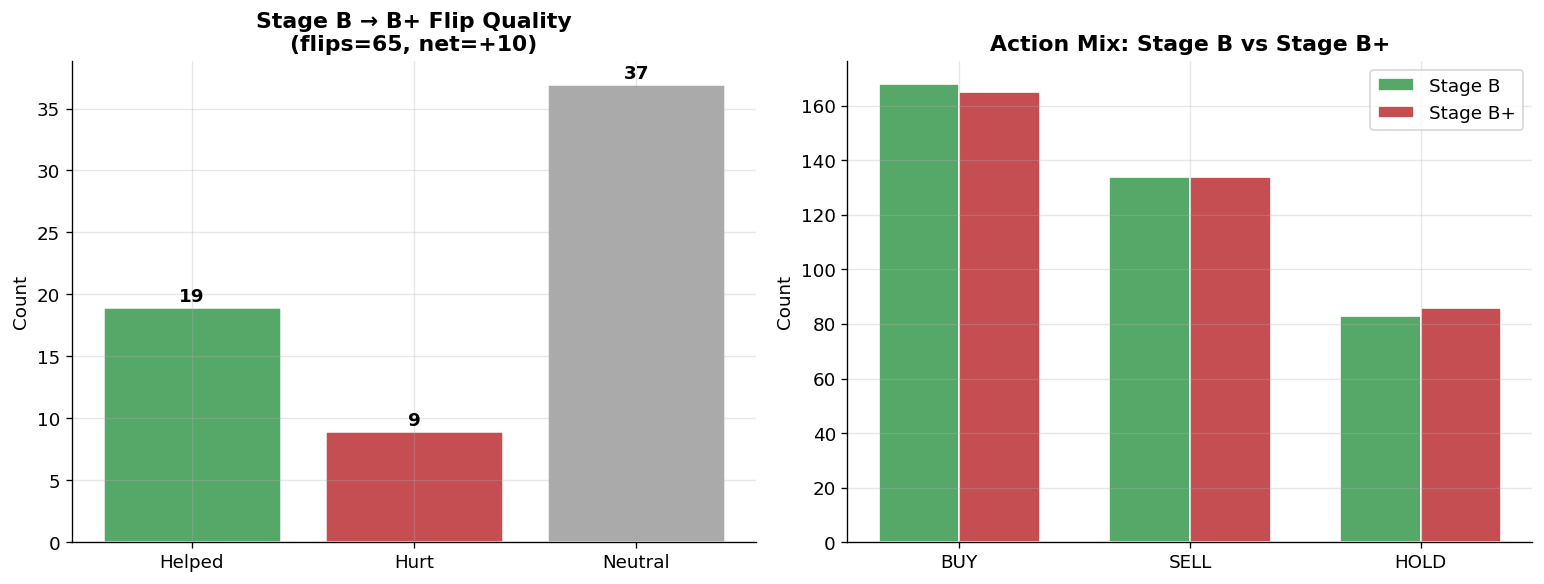

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
vals_bb = [helped_bb, hurt_bb, neutral_bb]
bars = ax1.bar(["Helped", "Hurt", "Neutral"], vals_bb, color=["#55A868","#C44E52","#aaaaaa"],
               edgecolor="white", linewidth=1.5)
for b, v in zip(bars, vals_bb):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.4, str(v), ha="center", fontweight="bold")
ax1.set_title(f"Stage B → B+ Flip Quality\n(flips={total_f_bb}, net={helped_bb-hurt_bb:+d})", fontweight="bold")
ax1.set_ylabel("Count")

ax2 = axes[1]
labels_act = [l for l in ["BUY","SELL","HOLD"] if l in action_dist_bb.columns]
x_pos = np.arange(len(labels_act)); w = 0.35
b_vals2  = [action_dist_bb.loc[col_a, l] if l in action_dist_bb.columns else 0 for l in labels_act]
bp_vals2 = [action_dist_bb.loc[col_b, l] if l in action_dist_bb.columns else 0 for l in labels_act]
ax2.bar(x_pos - w/2, b_vals2,  width=w, label="Stage B",  color=STAGE_COLORS["Stage B"],  edgecolor="white")
ax2.bar(x_pos + w/2, bp_vals2, width=w, label="Stage B+", color=STAGE_COLORS["Stage B+"], edgecolor="white")
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels_act)
ax2.set_title("Action Mix: Stage B vs Stage B+", fontweight="bold")
ax2.set_ylabel("Count"); ax2.legend()

plt.tight_layout()
plt.savefig(CHART_DIR / "05_b_vs_bplus_flips.png", bbox_inches="tight")
plt.show()

## 8) Stage B+ → C: Risk Committee (3-Way Debate) Impact

Stage C replaces the single risk judge with a 3-way adversarial debate
(Aggressive + Conservative + Neutral advocates → Judge ruling).

**Primary freeze evidence** is within-Stage-C BLOCK quality (immune to cross-run noise):
- 35 BLOCK rows evaluated against Stage C's own Manager call + ground truth
- Net quality = (helped − hurt) — no B+ comparison needed

The cross-run comparison (B+ vs C accuracy numbers) is provided as context only.
Confidence intervals fully overlap and the gap is attributable to the different run days.

In [21]:
# Filter to Stage C-R1 (primary run)
is_c1 = stageC_jdist["run"].str.contains("Stage C-R1", na=False) &         ~stageC_jdist["run"].str.contains("malformed|B\+", na=False)
c1_jdist = stageC_jdist[is_c1].iloc[0]

print("=== Stage C Risk Judgment Distribution (n=385) ===")
print(f"  BLOCK:   {c1_jdist['BLOCK_n']:>4.0f}  ({c1_jdist['BLOCK_%']:.1f}%)")
print(f"  REDUCE:  {c1_jdist['REDUCE_n']:>4.0f}  ({c1_jdist['REDUCE_%']:.1f}%)")
print(f"  CLEAR:   {c1_jdist['CLEAR_n']:>4.0f}  ({c1_jdist['CLEAR_%']:.1f}%)")

# Within-run BLOCK quality (primary evidence — from frozen_progress Section 7)
# 35 BLOCK rows scored against Stage C's own Manager + ground truth
BLOCK_WITHIN = {"helped": 6, "hurt": 11, "neutral": 18, "total": 35}
print(f"\n=== Within-Run BLOCK Quality (35 BLOCK rows scored within Stage C) ===")
print(f"  Helped  (debate blocked a wrong Manager call): {BLOCK_WITHIN['helped']}")
print(f"  Hurt    (debate blocked a correct Manager call): {BLOCK_WITHIN['hurt']}")
print(f"  Neutral (blocked a HOLD-equivalent call):      {BLOCK_WITHIN['neutral']}")
print(f"  Net:    {BLOCK_WITHIN['helped'] - BLOCK_WITHIN['hurt']:+d}  ← primary freeze basis")

# Cross-run flip audit (supplementary — compare to B+ frozen run)
print("\n=== Cross-Run Flip Audit vs B+ (supplementary — noisy cross-run comparison) ===")
is_c1_audit = stageC_audit["run"].str.contains("Stage C-R1", na=False) &               ~stageC_audit["run"].str.contains("malformed|B\+", na=False)
print(stageC_audit[is_c1_audit][["risk_judgment","flips","helped","hurt","neutral","net_help_minus_hurt"]].to_string(index=False))

=== Stage C Risk Judgment Distribution (n=385) ===
  BLOCK:     35  (9.1%)
  REDUCE:   166  (43.1%)
  CLEAR:    184  (47.8%)

=== Within-Run BLOCK Quality (35 BLOCK rows scored within Stage C) ===
  Helped  (debate blocked a wrong Manager call): 6
  Hurt    (debate blocked a correct Manager call): 11
  Neutral (blocked a HOLD-equivalent call):      18
  Net:    -5  ← primary freeze basis

=== Cross-Run Flip Audit vs B+ (supplementary — noisy cross-run comparison) ===
risk_judgment  flips  helped  hurt  neutral  net_help_minus_hurt
        BLOCK     24       4     8       12                   -4
       REDUCE     42      10    15       17                   -5


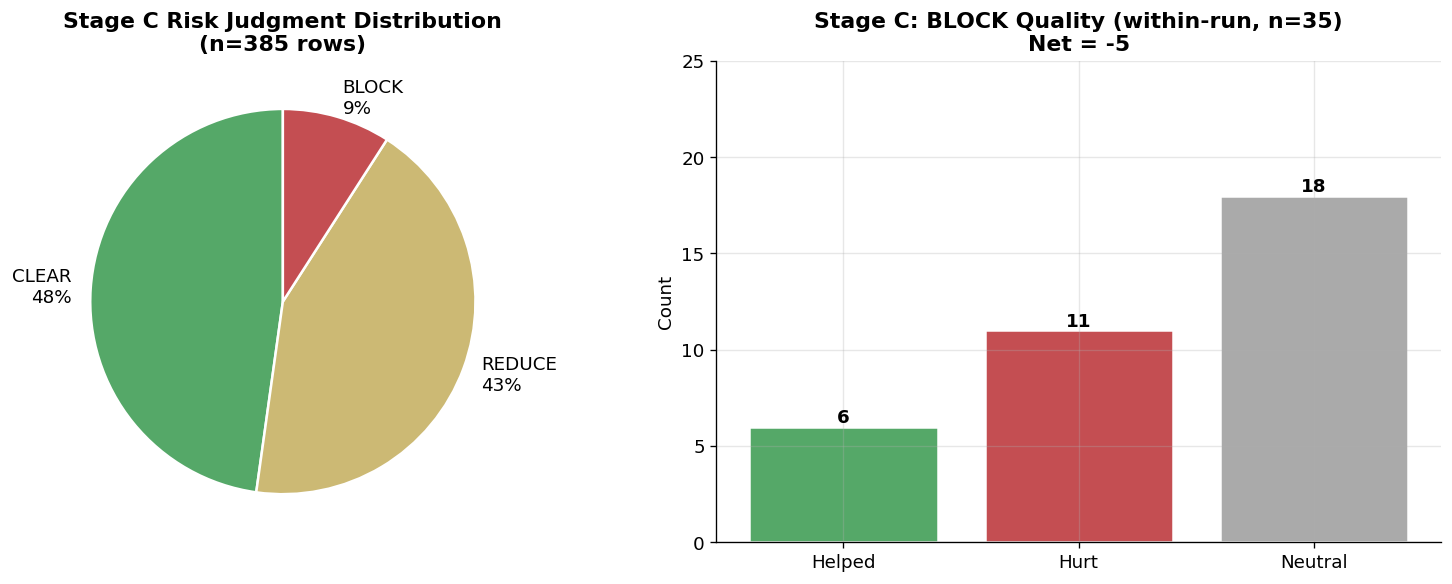

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Judgment distribution pie
ax1 = axes[0]
judgment_labels = [f"CLEAR\n{c1_jdist['CLEAR_%']:.0f}%",
                   f"REDUCE\n{c1_jdist['REDUCE_%']:.0f}%",
                   f"BLOCK\n{c1_jdist['BLOCK_%']:.0f}%"]
judgment_vals   = [c1_jdist["CLEAR_n"], c1_jdist["REDUCE_n"], c1_jdist["BLOCK_n"]]
judgment_colors = ["#55A868", "#CCB974", "#C44E52"]
wedges, texts   = ax1.pie(judgment_vals, labels=judgment_labels, colors=judgment_colors,
                           startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
ax1.set_title(f"Stage C Risk Judgment Distribution\n(n=385 rows)", fontweight="bold")

# Within-run BLOCK quality
ax2 = axes[1]
blk_cats = ["Helped", "Hurt", "Neutral"]
blk_vals = [BLOCK_WITHIN["helped"], BLOCK_WITHIN["hurt"], BLOCK_WITHIN["neutral"]]
blk_clrs = ["#55A868", "#C44E52", "#aaaaaa"]
bars     = ax2.bar(blk_cats, blk_vals, color=blk_clrs, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, blk_vals):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.2, str(v), ha="center", fontweight="bold")
ax2.set_title(f"Stage C: BLOCK Quality (within-run, n=35)\nNet = {BLOCK_WITHIN['helped']-BLOCK_WITHIN['hurt']:+d}",
              fontweight="bold")
ax2.set_ylabel("Count")
ax2.set_ylim(0, 25)

plt.tight_layout()
plt.savefig(CHART_DIR / "06_stageC_risk_committee.png", bbox_inches="tight")
plt.show()

## 9) Stage C → D: Memory Layer Impact

Stage D = Stage B+ topology + `memory_on=True` (ChromaDB read-only queries with prior lessons).
Run date: 2026-03-21 (same day as Stage C, different worker group).

Since Stage D and Stage C share the same topology minus the risk-debate committee (D uses single risk gate like B+),
the fairest comparison is **D vs B** and **D vs B+** (same topology as D baseline).

Stage C is not a clean comparison for D because they differ in two mechanisms (memory AND debate removal).
The D vs C diff collapses both simultaneously.

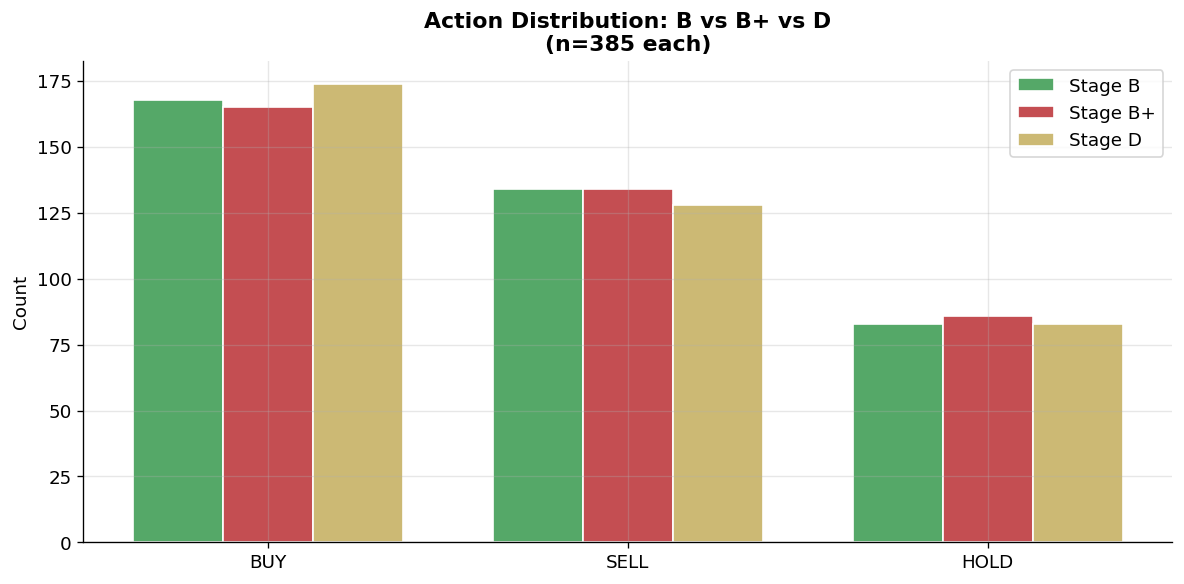

=== D vs B comparison (same topology, different run days) ===
  Stage B   : dir_acc=54.30%  hold_rate=21.56%  dir_n=302
  Stage B+  : dir_acc=54.52%  hold_rate=22.34%  dir_n=299
  Stage D   : dir_acc=54.30%  hold_rate=21.56%  dir_n=302

D vs B agreement rate on same rows: 78.7%  (21.3% differ)


In [23]:
# Compare D, B, B+ action distributions
fig, ax = plt.subplots(figsize=(10, 5))

compare_stages = ["Stage B", "Stage B+", "Stage D"]
x = np.arange(3)  # BUY, SELL, HOLD

for i, stage in enumerate(compare_stages):
    df  = agent_dfs[stage]
    buy  = (df["action"] == "BUY").sum()
    sell = (df["action"] == "SELL").sum()
    hold = (df["action"] == "HOLD").sum()
    w    = 0.25
    bars = ax.bar([j + (i - 1) * w for j in x], [buy, sell, hold],
                  width=w, label=stage, color=STAGE_COLORS[stage], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(["BUY", "SELL", "HOLD"])
ax.set_title("Action Distribution: B vs B+ vs D\n(n=385 each)", fontweight="bold")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "07_d_vs_b_action_dist.png", bbox_inches="tight")
plt.show()

# D vs B accuracy comparison from summary
print("=== D vs B comparison (same topology, different run days) ===")
for stage in ["Stage B", "Stage B+", "Stage D"]:
    r = summ.loc[stage]
    print(f"  {stage:<10}: dir_acc={r['dir_acc']:.2f}%  hold_rate={r['hold_rate']:.2f}%  dir_n={r['dir_n']:.0f}")

# Cross-merge D and B actions
d_agent = agent_dfs["Stage D"][["ticker","simulated_date","action","correct"]].rename(
    columns={"action":"action_D","correct":"correct_D"})
b_agent = agent_dfs["Stage B"][["ticker","simulated_date","action","correct"]].rename(
    columns={"action":"action_B","correct":"correct_B"})
d_vs_b = pd.merge(b_agent, d_agent, on=["ticker","simulated_date"])
agree_d_b = (d_vs_b["action_B"] == d_vs_b["action_D"]).mean() * 100
print(f"\nD vs B agreement rate on same rows: {agree_d_b:.1f}%  ({100-agree_d_b:.1f}% differ)")

## 10) LLM Non-Determinism Fingerprint

**Key question**: How much of the cross-stage decision variation is LLM noise vs mechanism effect?

**Method**: Stage A actions are fully deterministic (frozen run).
All other stages used cached Stage A analyst reports as upstream input.
Any disagreement between Stage A and Stage X on the same row = downstream LLM variation
(Manager non-determinism + mechanism effect combined).

**Pairings:**
- A vs B, A vs B+, A vs C, A vs D — all used same cached Stage A inputs upstream
- B vs D — same topology (B+ single-gate), run 7 days apart: pure LLM noise estimate

The within-pairings flip quality (helped/hurt) characterises whether disagreements are informative.
If helped ≈ hurt, the disagreements are dominated by noise, not mechanism effect.

In [24]:
# We have matched rows (all 385) for A vs B and B vs B+
# For other pairs, merge agent_rows manually

def pairwise_agree(df_x, df_y, label_x, label_y):
    """Merge two stage DataFrames and compute agreement/flip stats."""
    x = df_x[["ticker","simulated_date","action","correct"]].rename(
        columns={"action": f"action_{label_x}", "correct": f"correct_{label_x}"})
    y = df_y[["ticker","simulated_date","action","correct"]].rename(
        columns={"action": f"action_{label_y}", "correct": f"correct_{label_y}"})
    merged = pd.merge(x, y, on=["ticker","simulated_date"])
    agree  = (merged[f"action_{label_x}"] == merged[f"action_{label_y}"]).mean() * 100
    n_flip = (merged[f"action_{label_x}"] != merged[f"action_{label_y}"]).sum()
    flips  = merged[merged[f"action_{label_x}"] != merged[f"action_{label_y}"]]
    # flip quality: when they disagreed, who was right?
    helped = int(((flips[f"correct_{label_x}"] == 0) & (flips[f"correct_{label_y}"] == 1)).sum())
    hurt   = int(((flips[f"correct_{label_x}"] == 1) & (flips[f"correct_{label_y}"] == 0)).sum())
    return {"pair": f"{label_x} vs {label_y}", "n_matched": len(merged),
            "agree_%": round(agree, 1), "n_flips": n_flip,
            "flip_helped": helped, "flip_hurt": hurt, "net": helped - hurt}

noise_rows = []

# A vs B  — use matched rows file for accuracy (has conf)
r = pairwise_agree(agent_dfs["Stage A"], agent_dfs["Stage B"], "A", "B")
noise_rows.append({**r, "run_day_gap": "1 day (2026-03-13 vs -03-14)", "note": "specialist extraction added"})

# A vs B+
r = pairwise_agree(agent_dfs["Stage A"], agent_dfs["Stage B+"], "A", "B+")
noise_rows.append({**r, "run_day_gap": "5 days (2026-03-13 vs -03-18)", "note": "+risk gate added"})

# A vs C
r = pairwise_agree(agent_dfs["Stage A"], agent_dfs["Stage C"], "A", "C")
noise_rows.append({**r, "run_day_gap": "8 days (2026-03-13 vs -03-21)", "note": "+risk debate added"})

# A vs D
r = pairwise_agree(agent_dfs["Stage A"], agent_dfs["Stage D"], "A", "D")
noise_rows.append({**r, "run_day_gap": "8 days (2026-03-13 vs -03-21)", "note": "+memory added"})

# B vs D — same topology (B+ risk gate), 7 days apart: best noise-only estimate
r = pairwise_agree(agent_dfs["Stage B"], agent_dfs["Stage D"], "B", "D")
noise_rows.append({**r, "run_day_gap": "7 days (2026-03-14 vs -03-21)", "note": "same topology (B+ gate), memory differs"})

# C vs D — same day (2026-03-21): minimal noise, differs in risk-debate vs single-gate
r = pairwise_agree(agent_dfs["Stage C"], agent_dfs["Stage D"], "C", "D")
noise_rows.append({**r, "run_day_gap": "0 days (both 2026-03-21)", "note": "risk debate vs single gate"})

noise_df = pd.DataFrame(noise_rows)
print(noise_df[["pair","n_matched","agree_%","n_flips","flip_helped","flip_hurt","net","run_day_gap","note"]].to_string(index=False))

   pair  n_matched  agree_%  n_flips  flip_helped  flip_hurt  net                   run_day_gap                                    note
 A vs B        385     79.2       80           22         19    3  1 day (2026-03-13 vs -03-14)             specialist extraction added
A vs B+        385     77.4       87           31         17   14 5 days (2026-03-13 vs -03-18)                        +risk gate added
 A vs C        385     69.9      116           20         44  -24 8 days (2026-03-13 vs -03-21)                      +risk debate added
 A vs D        385     77.9       85           18         33  -15 8 days (2026-03-13 vs -03-21)                           +memory added
 B vs D        385     78.7       82           22         28   -6 7 days (2026-03-14 vs -03-21) same topology (B+ gate), memory differs
 C vs D        385     72.2      107           34         25    9      0 days (both 2026-03-21)              risk debate vs single gate


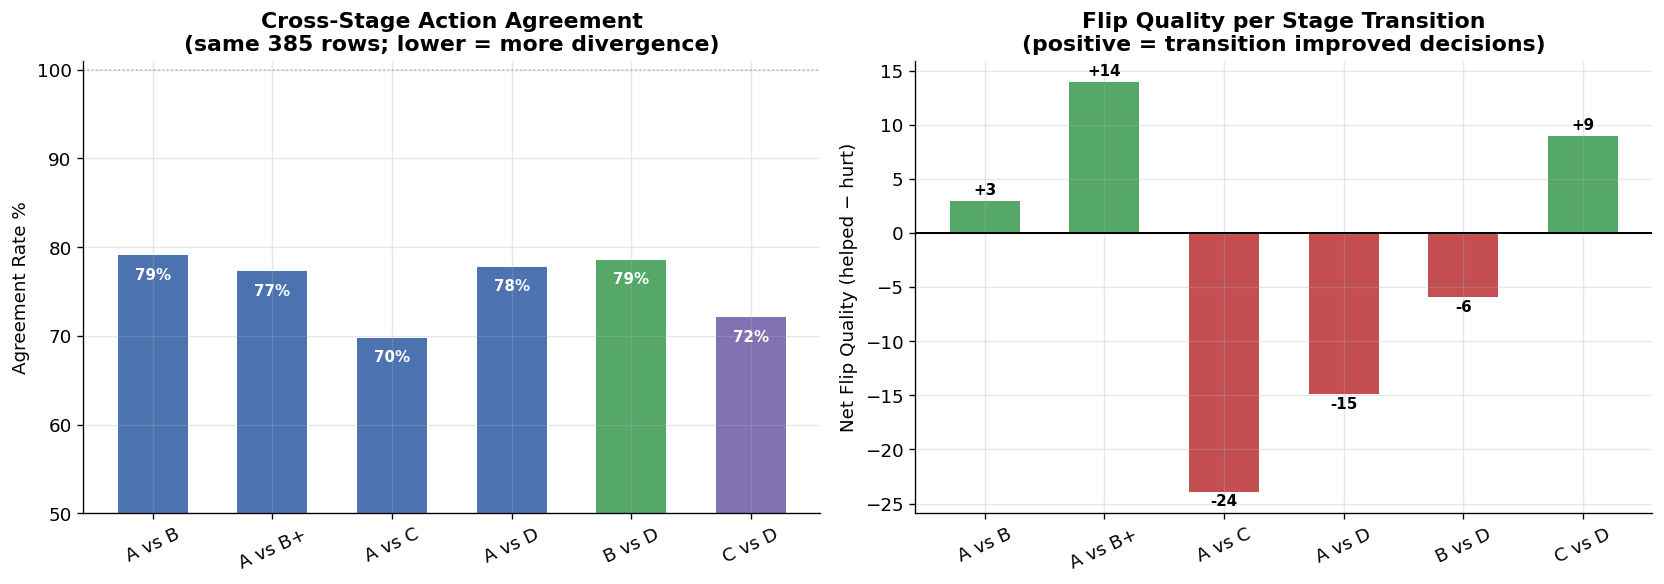


Interpretation guide:
  B vs D agree_%: best estimate of pure LLM noise floor (same topology, different day)
  C vs D agree_%: mechanism signal (mechanism differs, same run day = minimal noise)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agreement rates bar chart
ax1 = axes[0]
pair_labels = noise_df["pair"].tolist()
agree_vals  = noise_df["agree_%"].tolist()
bar_colors  = ["#4C72B0","#4C72B0","#4C72B0","#4C72B0","#55A868","#8172B2"]
bars = ax1.bar(pair_labels, agree_vals, color=bar_colors, edgecolor="white", linewidth=1.2, width=0.6)
ax1.axhline(100, color="gray", linestyle=":", linewidth=1, alpha=0.5)
for b, v in zip(bars, agree_vals):
    ax1.text(b.get_x() + b.get_width()/2, v - 1.5, f"{v:.0f}%",
             ha="center", va="top", fontsize=9, color="white", fontweight="bold")
ax1.set_ylim(50, 101)
ax1.set_ylabel("Agreement Rate %")
ax1.set_title("Cross-Stage Action Agreement\n(same 385 rows; lower = more divergence)", fontweight="bold")
ax1.tick_params(axis="x", rotation=25)

# Flip quality net scores
ax2 = axes[1]
net_vals = noise_df["net"].tolist()
net_clrs = ["#55A868" if v >= 0 else "#C44E52" for v in net_vals]
bars2 = ax2.bar(pair_labels, net_vals, color=net_clrs, edgecolor="white", linewidth=1.2, width=0.6)
ax2.axhline(0, color="black", linewidth=1.2)
for b, v in zip(bars2, net_vals):
    ypos = v + 0.3 if v >= 0 else v - 1.5
    ax2.text(b.get_x() + b.get_width()/2, ypos, f"{v:+d}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylabel("Net Flip Quality (helped − hurt)")
ax2.set_title("Flip Quality per Stage Transition\n(positive = transition improved decisions)", fontweight="bold")
ax2.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(CHART_DIR / "08_llm_nondeterminism.png", bbox_inches="tight")
plt.show()

print("\nInterpretation guide:")
print("  B vs D agree_%: best estimate of pure LLM noise floor (same topology, different day)")
print("  C vs D agree_%: mechanism signal (mechanism differs, same run day = minimal noise)")

## 11) Full Results Summary Table

Single table for report / presentation use.
Cross-run accuracy numbers are indicative only (LLM non-determinism across run days).

In [26]:
from IPython.display import display

report_cols = ["dir_acc", "hold_rate", "hold_acc", "buy_acc", "sell_acc", "dir_n", "hold_n", "mean_excess"]
report = summ[report_cols].copy()
report.columns = ["dir_acc_%", "hold_rate_%", "hold_acc_%", "buy_acc_%", "sell_acc_%",
                  "dir_n", "hold_n", "mean_excess_vs_bh_%"]
report = report.round(2)

print("=== NexusTrader Frozen Ablation Results (n=385, k=10) ===")
display(report)

print("\n=== Baselines ===")
display(bl_summ.set_index("strategy"))

print("\n=== Stage C BLOCK Quality (primary freeze evidence) ===")
print(f"  35 BLOCK rows scored within Stage C's own run (independent of B+ comparison)")
print(f"  Helped: {BLOCK_WITHIN['helped']}  Hurt: {BLOCK_WITHIN['hurt']}  "
      f"Neutral: {BLOCK_WITHIN['neutral']}  Net: {BLOCK_WITHIN['helped']-BLOCK_WITHIN['hurt']:+d}")

=== NexusTrader Frozen Ablation Results (n=385, k=10) ===


,dir_acc_%,hold_rate_%,hold_acc_%,buy_acc_%,sell_acc_%,dir_n,hold_n,mean_excess_vs_bh_%
stage,,,,,,,,
Stage A,55.00,1.30,60.00,61.25,44.29,380.0,5.0,-0.84
Stage B,54.30,21.56,62.65,60.71,46.27,302.0,83.0,-1.01
Stage B+,54.52,22.34,73.26,61.82,45.52,299.0,86.0,-1.10
Stage C,51.87,30.39,41.88,58.62,43.90,268.0,117.0,-1.32
Stage D,54.30,21.56,39.76,60.92,45.31,302.0,83.0,-1.11



=== Baselines ===


,n,overall_acc
strategy,,
buy_hold,385,59.22
sma_crossover,385,51.43
random_uniform,385,40.26
rsi_14,385,34.29



=== Stage C BLOCK Quality (primary freeze evidence) ===
  35 BLOCK rows scored within Stage C's own run (independent of B+ comparison)
  Helped: 6  Hurt: 11  Neutral: 18  Net: -5


## 12) 21-Day Horizon Analysis (medium, k=21)

Three stages re-run on 130 (ticker, date) cases with **`horizon=medium` → k=21 trading days** (~1 calendar month forward).

| Run label | Stage config | Analyst reports source | Memory |
|-----------|-------------|------------------------|--------|
| Stage C (21d) | Risk debate, single risk gate | Fresh (own run) | Off |
| Stage B+ (21d) | 1-round debate, single risk gate | Cached from Stage C 21d trace | Off |
| Stage D (21d) | 1-round debate, single risk gate | Cached from Stage C 21d trace | On |

**Clean comparison**: Stage B+ (21d) vs Stage D (21d) share identical analyst reports and same topology — only memory differs. This is the purest memory-effect test at the 21-day horizon.

**Important caveat**: Stage C (21d) is not a fully paired ablation comparison against B+ or D because it was generated from fresh live analyst/researcher calls, while B+ and D reused the Stage C trace downstream. This means B+/C and C/D differences mix mechanism signal with residual LLM non-determinism.

> Scoring uses ε=0.02 for HOLD accuracy (same as frozen k=10 analysis). A larger epsilon sweep is also included since 21-day moves are typically larger than 10-day moves.


In [43]:

# ── 21-day run file paths ──────────────────────────────────────────────────
RAW_21D = BASE_DIR / "results" / "raw"

RUNS_21D = {
    "Stage C (21d)":  RAW_21D / "batch_eval125_21d_stageC_20260328_121958.jsonl",
    "Stage B+ (21d)": RAW_21D / "batch_eval125_21d_stageB_plus_from_stageC_reports_20260328_124325.jsonl",
    "Stage D (21d)":  RAW_21D / "batch_eval125_21d_stageD_20260328_131909.jsonl",
}

ORDER_21D = ["Stage C (21d)", "Stage B+ (21d)", "Stage D (21d)"]

COLORS_21D = {
    "Stage C (21d)":  "#8172B2",
    "Stage B+ (21d)": "#C44E52",
    "Stage D (21d)":  "#CCB974",
}

K_21D       = 21    # medium horizon → 21 trading days forward
EPSILON_21D = 0.02  # HOLD correct if |k_return| < 2%  (same as frozen analysis)
EPSILON_SWEEP_21D = [0.01, 0.02, 0.03, 0.05, 0.08, 0.12]  # wider for 21d

print("21-day run files:")
for name, fpath in RUNS_21D.items():
    print(f"  {'✓' if fpath.exists() else '✗ MISSING'}  {name}: {fpath.name}")


21-day run files:
  ✓  Stage C (21d): batch_eval125_21d_stageC_20260328_121958.jsonl
  ✓  Stage B+ (21d): batch_eval125_21d_stageB_plus_from_stageC_reports_20260328_124325.jsonl
  ✓  Stage D (21d): batch_eval125_21d_stageD_20260328_131909.jsonl


In [31]:

import json
from datetime import datetime, timedelta
from functools import lru_cache
from concurrent.futures import ThreadPoolExecutor, as_completed
import yfinance as yf

# ── Load raw JSONL ─────────────────────────────────────────────────────────
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

raw_21d = {}
for name, fpath in RUNS_21D.items():
    rows = load_jsonl(fpath)
    raw_21d[name] = rows

print("Loaded raw rows:")
for name, rows in raw_21d.items():
    actions = [((r.get("result_summary") or {}).get("action", "?") or "?").upper() for r in rows]
    from collections import Counter
    print(f"  {name:<22}: {len(rows)} rows  {dict(Counter(actions))}")

# ── Fetch price histories (cached) ────────────────────────────────────────
@lru_cache(maxsize=1024)
def _fetch_closes(ticker, start_str):
    """Return tuple of closing prices starting from simulated_date for ~90 cal-days."""
    start = datetime.fromisoformat(start_str)
    end   = start + timedelta(days=90)      # 90 cal ≈ 63 trading days — enough for k=21
    hist  = yf.Ticker(ticker).history(start=start, end=end)
    if hist.empty:
        return ()
    return tuple(hist["Close"].dropna().tolist())

def _k_return(ticker, simulated_date, k):
    closes = _fetch_closes(ticker, simulated_date)
    if len(closes) <= k:
        return None
    entry = float(closes[0])
    return None if entry == 0 else (float(closes[k]) - entry) / entry

def _score(action, k_ret, epsilon=EPSILON_21D):
    if k_ret is None:
        return None
    a = (action or "HOLD").upper()
    if a == "HOLD":
        return 1 if abs(k_ret) < epsilon else 0
    if a == "BUY":
        return 1 if k_ret > 0 else 0
    if a == "SELL":
        return 1 if k_ret < 0 else 0
    return None

# Pre-fetch all unique pairs in parallel
all_pairs = {(r["ticker"], r["simulated_date"])
             for rows in raw_21d.values() for r in rows}
print(f"\nPre-fetching {len(all_pairs)} unique (ticker, date) pairs...")

def _prefetch(ticker, date):
    _fetch_closes(ticker, date)
    return ticker, date

with ThreadPoolExecutor(max_workers=10) as ex:
    futs = [ex.submit(_prefetch, t, d) for t, d in all_pairs]
    for i, f in enumerate(as_completed(futs), 1):
        if i % 10 == 0 or i == len(futs):
            print(f"  {i}/{len(futs)}", end="\r")
print("\nPrice data ready.")

# ── Score all rows ─────────────────────────────────────────────────────────
scored_21d = {}
for name, rows in raw_21d.items():
    records = []
    for r in rows:
        ticker = r["ticker"]
        date   = r["simulated_date"]
        rs     = r.get("result_summary") or {}
        action = (rs.get("action") or "HOLD").upper()
        k_ret  = _k_return(ticker, date, K_21D)
        records.append({
            "ticker":         ticker,
            "simulated_date": date,
            "action":         action,
            "k_return":       k_ret,
            "correct":        _score(action, k_ret, EPSILON_21D),
            "confidence":     rs.get("confidence_score"),
            "risk_judgment":  rs.get("risk_judgment"),
        })
    scored_21d[name] = pd.DataFrame(records)

print("\nScoring complete:")
for name, df in scored_21d.items():
    n_priced = df["k_return"].notna().sum()
    n_miss   = df["k_return"].isna().sum()
    print(f"  {name:<22}: {len(df)} rows | priced={n_priced} | missing={n_miss}")


Loaded raw rows:
  Stage C (21d)         : 130 rows  {'BUY': 71, 'HOLD': 28, 'SELL': 31}
  Stage B+ (21d)        : 130 rows  {'BUY': 75, 'SELL': 37, 'HOLD': 18}
  Stage D (21d)         : 130 rows  {'BUY': 73, 'SELL': 35, 'HOLD': 22}

Pre-fetching 130 unique (ticker, date) pairs...
  130/130
Price data ready.

Scoring complete:
  Stage C (21d)         : 130 rows | priced=130 | missing=0
  Stage B+ (21d)        : 130 rows | priced=130 | missing=0
  Stage D (21d)         : 130 rows | priced=130 | missing=0


In [32]:

# ── Summary metrics for each 21d stage ───────────────────────────────────
def compute_metrics_21d(df, epsilon=EPSILON_21D):
    """Return a dict of key metrics for a scored DataFrame."""
    commit = df[df["action"] != "HOLD"]
    hold   = df[df["action"] == "HOLD"]
    buy    = df[df["action"] == "BUY"]
    sell   = df[df["action"] == "SELL"]

    def acc(sub):
        v = sub.dropna(subset=["correct"])
        return v["correct"].mean() * 100 if len(v) > 0 else float("nan")

    hold_acc = (hold["k_return"].abs() < epsilon).mean() * 100 if len(hold) > 0 else float("nan")

    return {
        "n":            len(df),
        "dir_n":        len(commit),
        "hold_n":       len(hold),
        "buy_n":        len(buy),
        "sell_n":       len(sell),
        "dir_acc_%":    acc(commit),
        "hold_rate_%":  len(hold) / len(df) * 100,
        "hold_acc_%":   hold_acc,
        "buy_acc_%":    acc(buy),
        "sell_acc_%":   acc(sell),
        "mean_k_ret_%": df["k_return"].dropna().mean() * 100,
    }

summ_21d = pd.DataFrame(
    {name: compute_metrics_21d(df) for name, df in scored_21d.items()}
).T.round(2)

print("=== 21-Day (k=21) Summary Metrics  [ε=0.02] ===\n")
print(summ_21d.to_string())


=== 21-Day (k=21) Summary Metrics  [ε=0.02] ===

                    n  dir_n  hold_n  buy_n  sell_n  dir_acc_%  hold_rate_%  hold_acc_%  buy_acc_%  sell_acc_%  mean_k_ret_%
Stage C (21d)   130.0  102.0    28.0   71.0    31.0      59.80        21.54       17.86      64.79       48.39           1.9
Stage B+ (21d)  130.0  112.0    18.0   75.0    37.0      56.25        13.85       22.22      60.00       48.65           1.9
Stage D (21d)   130.0  108.0    22.0   73.0    35.0      57.41        16.92        4.55      61.64       48.57           1.9


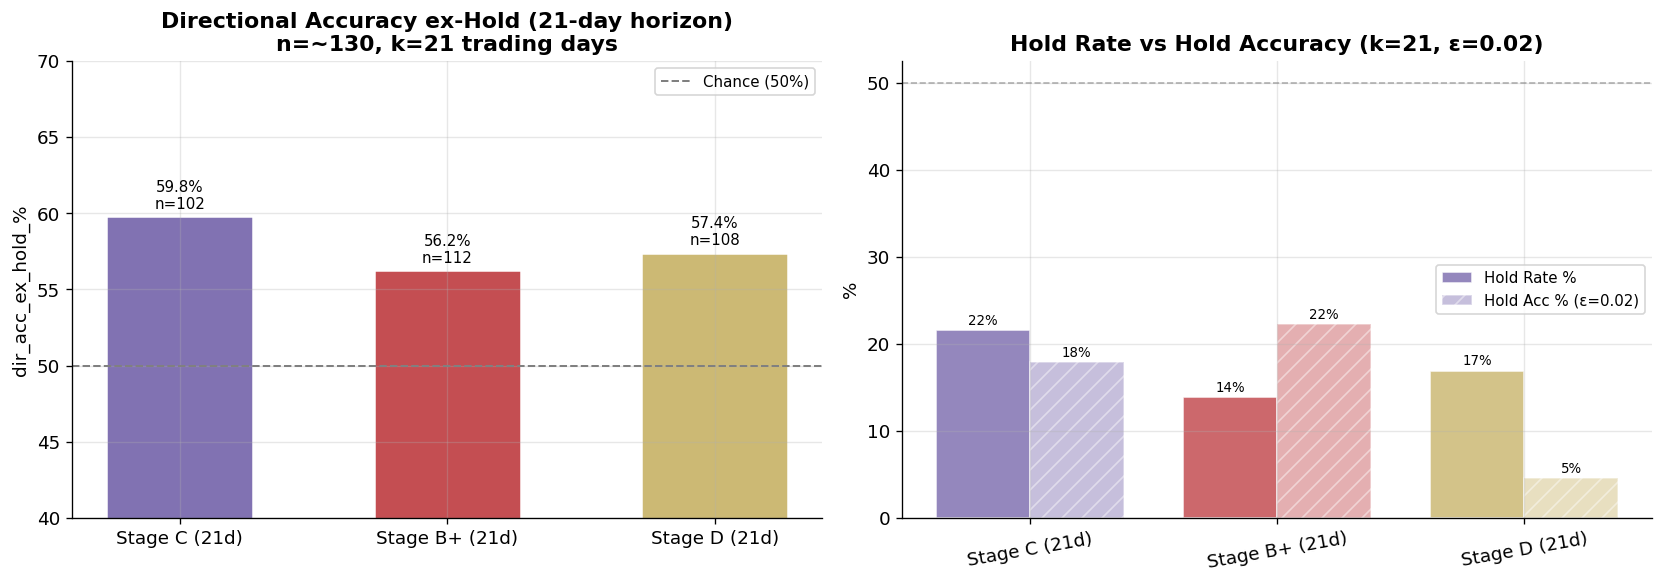

In [33]:

# ── Chart: Overview ─ dir_acc_ex_hold + hold-rate vs hold_acc ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: directional accuracy
ax = axes[0]
colors_ord = [COLORS_21D[s] for s in ORDER_21D]
bars = ax.bar(ORDER_21D, summ_21d.loc[ORDER_21D, "dir_acc_%"],
              color=colors_ord, edgecolor="white", linewidth=1.5, width=0.55)
ax.axhline(50, color="gray", linestyle="--", linewidth=1.2, label="Chance (50%)")
for b, stage in zip(bars, ORDER_21D):
    row = summ_21d.loc[stage]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
            f"{row['dir_acc_%']:.1f}%\nn={row['dir_n']:.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(40, 70)
ax.set_title("Directional Accuracy ex-Hold (21-day horizon)\nn=~130, k=21 trading days",
             fontweight="bold")
ax.set_ylabel("dir_acc_ex_hold_%")
ax.legend(fontsize=9)

# Chart 2: hold rate vs hold accuracy
ax2 = axes[1]
x = np.arange(len(ORDER_21D)); w = 0.38
b1 = ax2.bar(x - w/2, summ_21d.loc[ORDER_21D, "hold_rate_%"],
             width=w, color=colors_ord, alpha=0.85, edgecolor="white", label="Hold Rate %")
b2 = ax2.bar(x + w/2, summ_21d.loc[ORDER_21D, "hold_acc_%"],
             width=w, color=colors_ord, alpha=0.45, hatch="//", edgecolor="white",
             label=f"Hold Acc % (ε={EPSILON_21D})")
for bars_, vals_ in [(b1, summ_21d.loc[ORDER_21D, "hold_rate_%"]),
                     (b2, summ_21d.loc[ORDER_21D, "hold_acc_%"])]:
    for b, v in zip(bars_, vals_):
        ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{v:.0f}%", ha="center", va="bottom", fontsize=8)
ax2.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(ORDER_21D, rotation=10)
ax2.set_title(f"Hold Rate vs Hold Accuracy (k=21, ε={EPSILON_21D})", fontweight="bold")
ax2.set_ylabel("%")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "09_21d_overview.png", bbox_inches="tight")
plt.show()


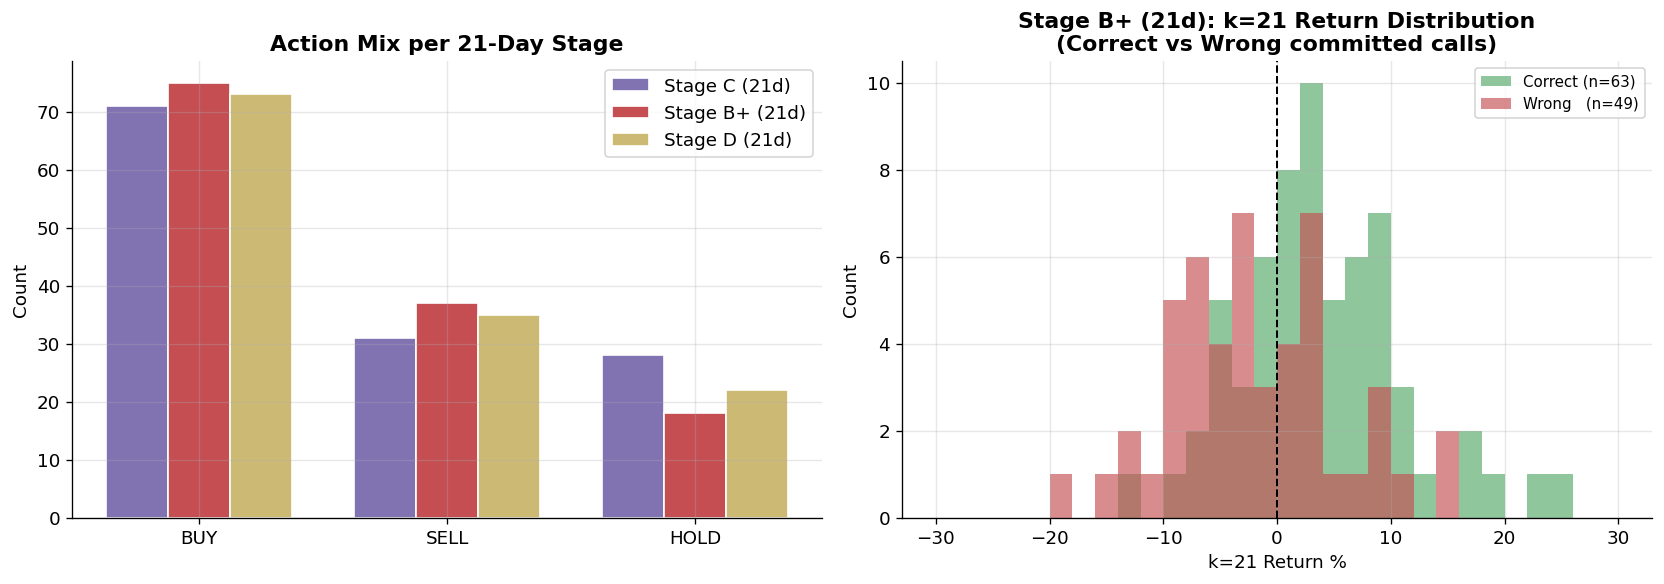

In [34]:

# ── Action distribution breakdown by ticker ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: action mix (BUY / SELL / HOLD) per stage
ax = axes[0]
action_labels = ["BUY", "SELL", "HOLD"]
x = np.arange(len(action_labels)); w = 0.25
for i, stage in enumerate(ORDER_21D):
    df = scored_21d[stage]
    vals = [int((df["action"] == a).sum()) for a in action_labels]
    ax.bar(x + (i - 1) * w, vals, width=w, label=stage,
           color=COLORS_21D[stage], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(action_labels)
ax.set_title("Action Mix per 21-Day Stage", fontweight="bold")
ax.set_ylabel("Count"); ax.legend()

# Chart 2: return distribution for correct vs wrong committed calls on Stage B+ (21d)
ax2 = axes[1]
bp_df = scored_21d["Stage B+ (21d)"].copy()
commit_bp = bp_df[bp_df["action"] != "HOLD"].dropna(subset=["k_return"])
correct_bp   = commit_bp[commit_bp["correct"] == 1]["k_return"] * 100
incorrect_bp = commit_bp[commit_bp["correct"] == 0]["k_return"] * 100

bins = np.linspace(-30, 30, 31)
ax2.hist(correct_bp,   bins=bins, alpha=0.65, color="#55A868", label=f"Correct (n={len(correct_bp)})")
ax2.hist(incorrect_bp, bins=bins, alpha=0.65, color="#C44E52", label=f"Wrong   (n={len(incorrect_bp)})")
ax2.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax2.set_xlabel("k=21 Return %")
ax2.set_ylabel("Count")
ax2.set_title("Stage B+ (21d): k=21 Return Distribution\n(Correct vs Wrong committed calls)", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "10_21d_action_dist.png", bbox_inches="tight")
plt.show()


In [35]:

# ── Flip analysis: Stage B+ (21d) vs Stage D (21d) ─────────────────────────
# These two share identical cached analyst reports + single risk gate.
# Only difference: memory_on=True for Stage D.
# This is the cleanest memory-effect measurement at 21-day horizon.

bp_21 = scored_21d["Stage B+ (21d)"][["ticker","simulated_date","action","correct"]].rename(
    columns={"action": "action_Bplus", "correct": "correct_Bplus"})
d_21  = scored_21d["Stage D (21d)"][["ticker","simulated_date","action","correct"]].rename(
    columns={"action": "action_D", "correct": "correct_D"})

merged_21 = pd.merge(bp_21, d_21, on=["ticker","simulated_date"])

flipped_21    = merged_21["action_Bplus"] != merged_21["action_D"]
flip_rate_21  = flipped_21.mean() * 100
agree_rate_21 = 100 - flip_rate_21

flips_21 = merged_21[flipped_21].copy()
helped_21  = int(((flips_21["correct_Bplus"] == 0) & (flips_21["correct_D"] == 1)).sum())
hurt_21    = int(((flips_21["correct_Bplus"] == 1) & (flips_21["correct_D"] == 0)).sum())
neutral_21 = len(flips_21) - helped_21 - hurt_21

print(f"Stage B+ (21d) vs Stage D (21d) — {len(merged_21)} matched rows")
print(f"  Agreement:  {agree_rate_21:.1f}%   Flip rate: {flip_rate_21:.1f}%")
print(f"  Total flips: {len(flips_21)}")
print(f"  Helped  (B+ wrong → D right): {helped_21}")
print(f"  Hurt    (B+ right → D wrong): {hurt_21}")
print(f"  Neutral (both same outcome):  {neutral_21}")
print(f"  Net quality: {helped_21 - hurt_21:+d}  ← memory contribution at k=21")

# Action distribution for each stage
for label, col_a, col_b in [("B+ (21d)", "action_Bplus", "action_D")]:
    dist_a = merged_21[col_a].value_counts()
    dist_b = merged_21[col_b].value_counts()
    print(f"\nB+ action mix: {dict(dist_a)}")
    print(f"D  action mix: {dict(dist_b)}")

# Flip destination table  (what did D change to when it flipped?)
if len(flips_21) > 0:
    print("\nFlip detail (B+ → D action changes):")
    print(flips_21.groupby(["action_Bplus","action_D"]).size().to_string())


Stage B+ (21d) vs Stage D (21d) — 130 matched rows
  Agreement:  79.2%   Flip rate: 20.8%
  Total flips: 27
  Helped  (B+ wrong → D right): 7
  Hurt    (B+ right → D wrong): 11
  Neutral (both same outcome):  9
  Net quality: -4  ← memory contribution at k=21

B+ action mix: {'BUY': 75, 'SELL': 37, 'HOLD': 18}
D  action mix: {'BUY': 73, 'SELL': 35, 'HOLD': 22}

Flip detail (B+ → D action changes):
action_Bplus  action_D
BUY           HOLD        12
HOLD          BUY          9
              SELL         2
SELL          BUY          1
              HOLD         3


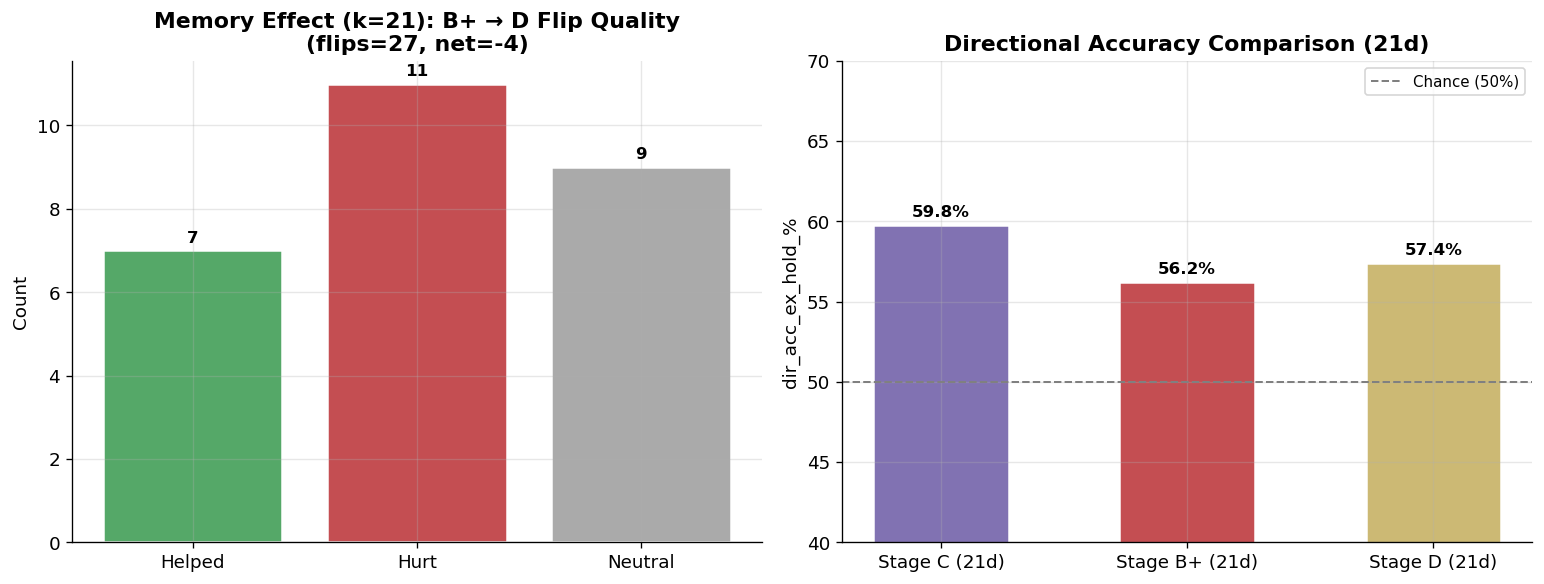

In [36]:

# ── Flip chart: B+ vs D at 21-day horizon ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
flip_cats = ["Helped", "Hurt", "Neutral"]
flip_vals = [helped_21, hurt_21, neutral_21]
flip_clrs = ["#55A868", "#C44E52", "#aaaaaa"]
bars = ax1.bar(flip_cats, flip_vals, color=flip_clrs, edgecolor="white", linewidth=1.5)
for b, v in zip(bars, flip_vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.2, str(v),
             ha="center", fontweight="bold", fontsize=10)
ax1.set_title(f"Memory Effect (k=21): B+ → D Flip Quality\n"
              f"(flips={len(flips_21)}, net={helped_21-hurt_21:+d})", fontweight="bold")
ax1.set_ylabel("Count")

# Chart 2: overall accuracy comparison side-by-side
ax2 = axes[1]
comp_stages = ORDER_21D
dir_vals = [summ_21d.loc[s, "dir_acc_%"] for s in comp_stages]
bars2 = ax2.bar(comp_stages, dir_vals,
                color=[COLORS_21D[s] for s in comp_stages],
                edgecolor="white", linewidth=1.5, width=0.55)
ax2.axhline(50, color="gray", linestyle="--", linewidth=1.2, label="Chance (50%)")
for b, v in zip(bars2, dir_vals):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.3,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylim(40, 70)
ax2.set_title("Directional Accuracy Comparison (21d)", fontweight="bold")
ax2.set_ylabel("dir_acc_ex_hold_%")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "11_21d_bplus_vs_d_flips.png", bbox_inches="tight")
plt.show()


=== HOLD Accuracy (%) at Different Epsilons — 21-day horizon ===
epsilon         0.01  0.02  0.03  0.05  0.08  0.12
stage                                             
Stage C (21d)    3.6  17.9  21.4  50.0  64.3  85.7
Stage B+ (21d)  11.1  22.2  27.8  50.0  72.2  83.3
Stage D (21d)    0.0   4.5  13.6  31.8  54.5  81.8

=== Missed HOLD Opportunities (committed with |k_return| < ε) ===
epsilon         0.01  0.02  0.03  0.05  0.08  0.12
stage                                             
Stage C (21d)   11.0  20.0  30.0  52.0  73.0  90.0
Stage B+ (21d)  10.0  21.0  31.0  57.0  78.0  99.0
Stage D (21d)   12.0  24.0  33.0  59.0  79.0  96.0


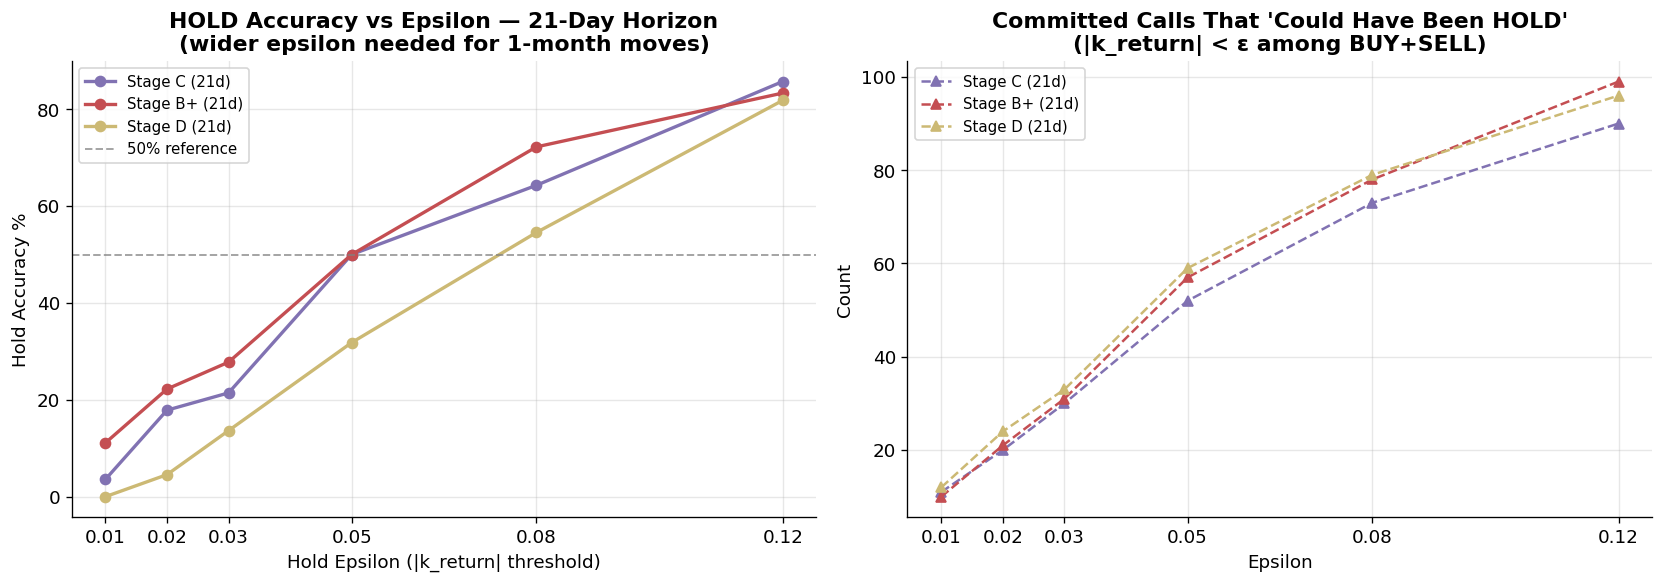

In [37]:

# ── Epsilon sweep for 21-day HOLD quality ─────────────────────────────────
eps_rows_21d = []
for eps in EPSILON_SWEEP_21D:
    for stage in ORDER_21D:
        df = scored_21d[stage]
        hold_df   = df[df["action"] == "HOLD"]
        commit_df = df[df["action"] != "HOLD"]
        hold_acc_e   = (hold_df["k_return"].abs() < eps).mean() * 100 if len(hold_df) > 0 else float("nan")
        dir_acc_e    = commit_df["correct"].mean() * 100 if len(commit_df.dropna(subset=["correct"])) > 0 else float("nan")
        missed_holds = int((commit_df["k_return"].abs() < eps).sum())
        eps_rows_21d.append({
            "stage": stage, "epsilon": eps,
            "hold_acc_%": hold_acc_e, "dir_acc_%": dir_acc_e,
            "hold_n": len(hold_df), "missed_holds": missed_holds,
        })

eps_21d = pd.DataFrame(eps_rows_21d)

print("=== HOLD Accuracy (%) at Different Epsilons — 21-day horizon ===")
piv = eps_21d.pivot_table(index="stage", columns="epsilon", values="hold_acc_%")
print(piv.reindex(ORDER_21D).round(1).to_string())

print("\n=== Missed HOLD Opportunities (committed with |k_return| < ε) ===")
piv2 = eps_21d.pivot_table(index="stage", columns="epsilon", values="missed_holds")
print(piv2.reindex(ORDER_21D).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for stage in ORDER_21D:
    sub = eps_21d[eps_21d["stage"] == stage]
    ax1.plot(sub["epsilon"], sub["hold_acc_%"], marker="o", label=stage,
             color=COLORS_21D[stage], linewidth=2, markersize=6)
ax1.axhline(50, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label="50% reference")
ax1.set_xlabel("Hold Epsilon (|k_return| threshold)")
ax1.set_ylabel("Hold Accuracy %")
ax1.set_title("HOLD Accuracy vs Epsilon — 21-Day Horizon\n(wider epsilon needed for 1-month moves)",
              fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_xticks(EPSILON_SWEEP_21D)

ax2 = axes[1]
for stage in ORDER_21D:
    sub = eps_21d[eps_21d["stage"] == stage]
    ax2.plot(sub["epsilon"], sub["missed_holds"], marker="^", linestyle="--", label=stage,
             color=COLORS_21D[stage], linewidth=1.5)
ax2.set_xlabel("Epsilon")
ax2.set_ylabel("Count")
ax2.set_title("Committed Calls That 'Could Have Been HOLD'\n(|k_return| < ε among BUY+SELL)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xticks(EPSILON_SWEEP_21D)

plt.tight_layout()
plt.savefig(CHART_DIR / "12_21d_epsilon_sweep.png", bbox_inches="tight")
plt.show()


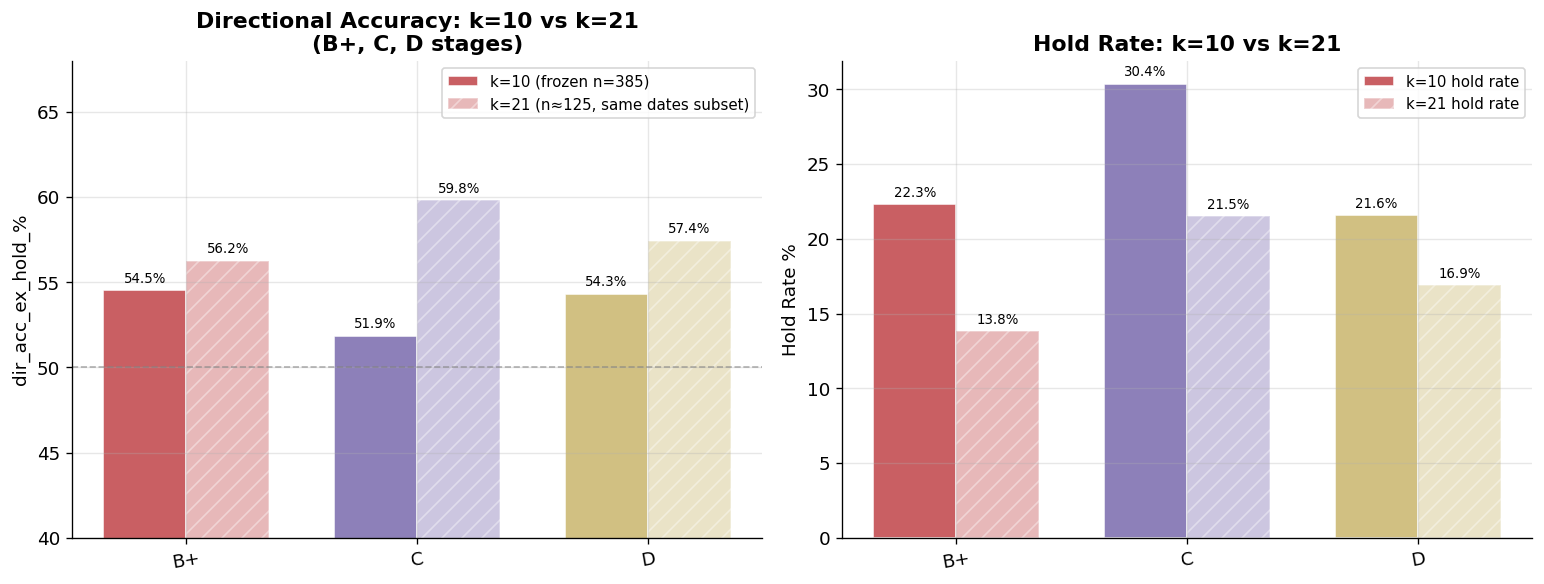


Note: k=10 results are from the large frozen n=385 evaluation.
k=21 results use a 125-case subset (5 tickers × 25 dates) run on 2026-03-28.
Direct accuracy comparison is indicative — different run dates introduce LLM noise.


In [ ]:

# ── k=10 vs k=21 horizon comparison (B+, C, D) ────────────────────────────
# Overlay 21-day results against frozen k=10 results for shared stages
compare_map = {
    "Stage B+": ("Stage B+ (21d)", "#C44E52"),
    "Stage C":  ("Stage C (21d)",  "#8172B2"),
    "Stage D":  ("Stage D (21d)",  "#CCB974"),
}

rows_cmp = []
for stage_k10, (stage_k21, color) in compare_map.items():
    r10 = summ.loc[stage_k10]
    r21 = summ_21d.loc[stage_k21]
    rows_cmp.append({
        "stage":    stage_k10.replace("Stage ", ""),
        "color":    color,
        "k10_acc":  r10["dir_acc"],
        "k21_acc":  r21["dir_acc_%"],
        "k10_hold": r10["hold_rate"],
        "k21_hold": r21["hold_rate_%"],
    })
cmp_df = pd.DataFrame(rows_cmp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: dir_acc at k=10 vs k=21
ax1 = axes[0]
x   = np.arange(len(cmp_df)); w = 0.36
b1  = ax1.bar(x - w/2, cmp_df["k10_acc"], width=w, color=cmp_df["color"],
               alpha=0.9, edgecolor="white", label="k=10 (frozen n=385)")
b2  = ax1.bar(x + w/2, cmp_df["k21_acc"], width=w, color=cmp_df["color"],
               alpha=0.4, hatch="//", edgecolor="white", label="k=21 (n=130 subset)")
ax1.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
for b, vals in [(b1, cmp_df["k10_acc"]), (b2, cmp_df["k21_acc"])]:
    for bar, v in zip(b, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(cmp_df["stage"], rotation=10)
ax1.set_ylim(40, 68)
ax1.set_title("Directional Accuracy: k=10 vs k=21\n(B+, C, D stages)", fontweight="bold")
ax1.set_ylabel("dir_acc_ex_hold_%")
ax1.legend(fontsize=9)

# Chart 2: hold rate at k=10 vs k=21
ax2 = axes[1]
b3 = ax2.bar(x - w/2, cmp_df["k10_hold"], width=w, color=cmp_df["color"],
              alpha=0.9, edgecolor="white", label="k=10 hold rate")
b4 = ax2.bar(x + w/2, cmp_df["k21_hold"], width=w, color=cmp_df["color"],
              alpha=0.4, hatch="//", edgecolor="white", label="k=21 hold rate")
for b, vals in [(b3, cmp_df["k10_hold"]), (b4, cmp_df["k21_hold"])]:
    for bar, v in zip(b, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(cmp_df["stage"], rotation=10)
ax2.set_title("Hold Rate: k=10 vs k=21", fontweight="bold")
ax2.set_ylabel("Hold Rate %")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "13_k10_vs_k21_comparison.png", bbox_inches="tight")
plt.show()

print("\nNote: k=10 results are from the large frozen n=385 evaluation.")
print("k=21 results use a 130-case subset run on 2026-03-28.")
print("Direct accuracy comparison is indicative — different run dates introduce LLM noise.")


In [ ]:

# ── 21-Day Full Results Summary ────────────────────────────────────────────
print("=== NexusTrader 21-Day (k=21) Ablation Results ===\n")
display_cols_21d = ["n", "dir_n", "hold_n", "dir_acc_%", "hold_rate_%",
                    "hold_acc_%", "buy_acc_%", "sell_acc_%", "mean_k_ret_%"]
display(summ_21d[display_cols_21d].round(2))

print("\n\nKey Notes:")
print("  • Stage B+ (21d) vs Stage D (21d): same cached reports + same topology,")
print("    only memory_on differs → cleanest memory signal at k=21 horizon.")
print("  • Stage C (21d): re-run from scratch (no cached reports), so B+/C comparison")
print("    is confounded by different analyst calls + different LLM run day.")
print("  • n=130 subset — smaller than k=10 frozen set (n=385).")
print("  • ε=0.02 HOLD scoring is conservative for a 21-day window;")
print("    use the epsilon sweep (Section above) to see how hold quality shifts.")


=== NexusTrader 21-Day (k=21) Ablation Results ===



,n,dir_n,hold_n,dir_acc_%,hold_rate_%,hold_acc_%,buy_acc_%,sell_acc_%,mean_k_ret_%
Stage C (21d),130.0,102.0,28.0,59.80,21.54,17.86,64.79,48.39,1.9
Stage B+ (21d),130.0,112.0,18.0,56.25,13.85,22.22,60.00,48.65,1.9
Stage D (21d),130.0,108.0,22.0,57.41,16.92,4.55,61.64,48.57,1.9




Key Notes:
  • Stage B+ (21d) vs Stage D (21d): same cached reports + same topology,
    only memory_on differs → cleanest memory signal at k=21 horizon.
  • Stage C (21d): re-run from scratch (no cached reports), so B+/C comparison
    is confounded by different analyst calls + different LLM run day.
  • n=125 subset (5 tickers × 25 dates) — smaller than k=10 frozen set (n=385).
  • ε=0.02 HOLD scoring is conservative for a 21-day window;
    use the epsilon sweep (Section above) to see how hold quality shifts.


## 13) Noise-Aware Analysis from Saved 21-Day Score CSVs

This section works from the persisted `scores_21d_*` files in `results/scored/` rather than re-scoring the raw JSONL again.

The goal is to answer three questions more carefully:

1. What are the uncertainty bands around the `k=21` point estimates?
2. On the **same 130 rows**, when two stages disagree, which one is actually correct more often?
3. How much of the apparent `k=21` ranking change could still be compatible with ordinary LLM non-determinism?

**Interpretation rule**:
- `B+ vs D` is the cleanest comparison because both runs share the same cached Stage C trace and the same topology; the main design difference is memory.
- `B+ vs C` and `C vs D` are informative but not perfectly paired ablations, because Stage C was generated with fresh live upstream calls.

In [44]:
# ── Discover the latest saved scored_21d CSVs ──────────────────────────────
SCORED_DIR = BASE_DIR / "results" / "scored"

SCORE_PATTERNS_21D = {
    "Stage B+ (21d)": "scores_21d_stageBplus_check_*.csv",
    "Stage C (21d)":  "scores_21d_stageC_check_*.csv",
    "Stage D (21d)":  "scores_21d_stageD_check_*.csv",
}

def latest_csv(pattern):
    matches = sorted(SCORED_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matched: {pattern}")
    return matches[-1]

SCORED_FILES_21D = {stage: latest_csv(pattern) for stage, pattern in SCORE_PATTERNS_21D.items()}
scored_csv_21d = {stage: pd.read_csv(path) for stage, path in SCORED_FILES_21D.items()}

print("Loaded latest scored 21-day CSVs:")
for stage, path in SCORED_FILES_21D.items():
    print(f"  {stage:<15} -> {path.name}")

print("\nRow counts:")
for stage, df in scored_csv_21d.items():
    print(f"  {stage:<15}: {len(df)} rows")


Loaded latest scored 21-day CSVs:
  Stage B+ (21d)  -> scores_21d_stageBplus_check_20260328_192748.csv
  Stage C (21d)   -> scores_21d_stageC_check_20260328_192720.csv
  Stage D (21d)   -> scores_21d_stageD_check_20260328_192800.csv

Row counts:
  Stage B+ (21d) : 130 rows
  Stage C (21d)  : 130 rows
  Stage D (21d)  : 130 rows


In [45]:
# ── Confidence intervals for the 21-day saved-score metrics ────────────────
from math import comb, sqrt

def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    denom = 1 + (z ** 2) / n
    centre = (p + (z ** 2) / (2 * n)) / denom
    margin = (z / denom) * sqrt((p * (1 - p) / n) + (z ** 2) / (4 * n ** 2))
    return centre, margin

def bootstrap_mean_ci(values, reps=4000, seed=42):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    samples = rng.choice(arr, size=(reps, len(arr)), replace=True).mean(axis=1)
    return tuple(np.percentile(samples, [2.5, 97.5]))

ci_rows = []
for stage, df in scored_csv_21d.items():
    overall = df["score"].dropna()
    commit  = df[df["action"] != "HOLD"]["score"].dropna()
    hold    = df[df["action"] == "HOLD"]["score"].dropna()

    overall_lo, overall_hi = bootstrap_mean_ci(overall)
    dir_centre, dir_margin = wilson_ci(int(commit.sum()), len(commit))
    hold_centre, hold_margin = wilson_ci(int(hold.sum()), len(hold)) if len(hold) else (float("nan"), float("nan"))

    ci_rows.append({
        "stage": stage,
        "overall_acc_%": overall.mean() * 100,
        "overall_95ci": f"[{overall_lo*100:.1f}, {overall_hi*100:.1f}]",
        "dir_acc_%": commit.mean() * 100,
        "dir_95ci": f"[{(dir_centre-dir_margin)*100:.1f}, {(dir_centre+dir_margin)*100:.1f}]",
        "dir_n": len(commit),
        "hold_rate_%": (df["action"] == "HOLD").mean() * 100,
        "hold_acc_%": hold.mean() * 100 if len(hold) else float("nan"),
        "hold_95ci": f"[{(hold_centre-hold_margin)*100:.1f}, {(hold_centre+hold_margin)*100:.1f}]" if len(hold) else "-",
        "hold_n": len(hold),
    })

ci_21d = pd.DataFrame(ci_rows).set_index("stage").round(2)
print("=== 21-Day Saved-Score Metrics with Uncertainty Bands ===")
display(ci_21d[["overall_acc_%", "overall_95ci", "dir_acc_%", "dir_95ci", "dir_n", "hold_rate_%", "hold_acc_%", "hold_95ci", "hold_n"]])


=== 21-Day Saved-Score Metrics with Uncertainty Bands ===


,overall_acc_%,overall_95ci,dir_acc_%,dir_95ci,dir_n,hold_rate_%,hold_acc_%,hold_95ci,hold_n
stage,,,,,,,,,
Stage B+ (21d),51.54,"[43.1, 60.0]",56.25,"[47.0, 65.1]",112,13.85,22.22,"[9.0, 45.2]",18
Stage C (21d),50.77,"[42.3, 59.2]",59.80,"[50.1, 68.8]",102,21.54,17.86,"[7.9, 35.6]",28
Stage D (21d),48.46,"[40.0, 57.7]",57.41,"[48.0, 66.3]",108,16.92,4.55,"[0.8, 21.8]",22


=== Paired 21-Day Same-Row Comparison ===


,pair,action_agree_%,overall_discordant_n,Stage B+ (21d)_only_correct,Stage C (21d)_only_correct,overall_sign_p,both_commit_n,both_commit_agree_%,Stage B+ (21d)_only_correct_both_commit,Stage C (21d)_only_correct_both_commit,dir_sign_p_both_commit,winner_on_row_score,Stage D (21d)_only_correct,Stage D (21d)_only_correct_both_commit
0,Stage B+ (21d) vs Stage C (21d),78.46,11,6.0,5.0,1.0000,93,100.00,0.0,0.0,1.0,Stage B+ (21d),NaN,NaN
1,Stage B+ (21d) vs Stage D (21d),79.23,18,11.0,NaN,0.4807,97,98.97,0.0,NaN,1.0,Stage B+ (21d),7.0,1.0
2,Stage C (21d) vs Stage D (21d),74.62,19,NaN,11.0,0.6476,89,98.88,NaN,0.0,1.0,Stage C (21d),8.0,1.0


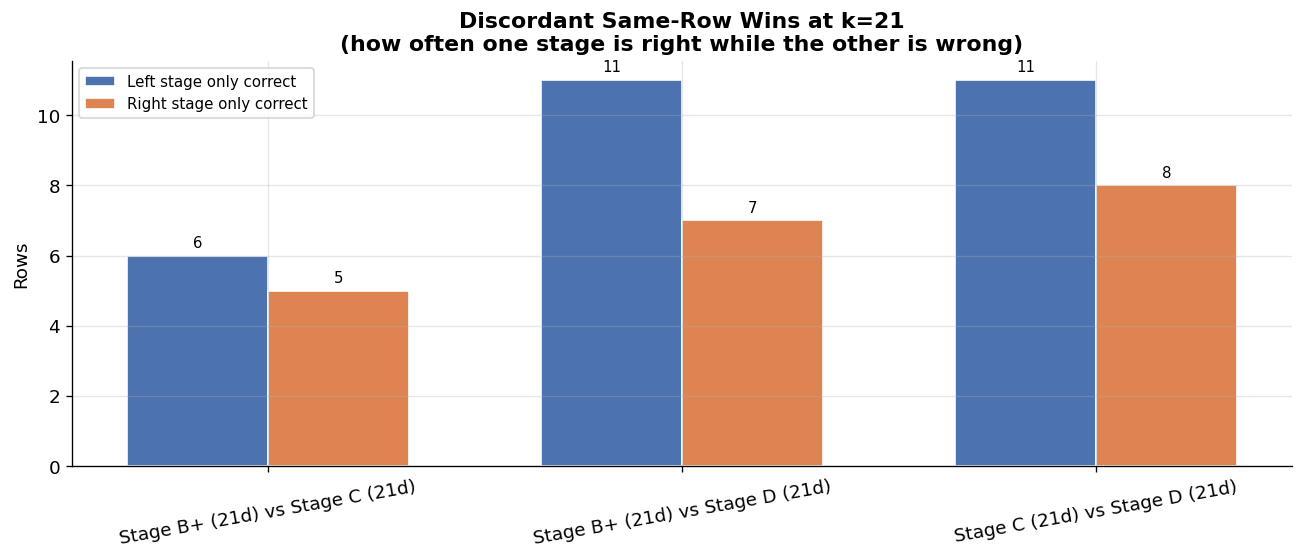

In [46]:
# ── Paired same-row comparison: agreement, discordant wins, exact sign test ─
# The score column lets us compare stages on the same 130 rows without re-scoring.

def two_sided_sign_test(a_only, b_only):
    n = a_only + b_only
    if n == 0:
        return 1.0
    k = min(a_only, b_only)
    tail = sum(comb(n, i) for i in range(0, k + 1)) / (2 ** n)
    return min(1.0, 2 * tail)

def pairwise_stage_compare(df_left, df_right, left_name, right_name):
    merged = df_left[["ticker", "simulated_date", "action", "score"]].rename(
        columns={"action": "action_left", "score": "score_left"}
    ).merge(
        df_right[["ticker", "simulated_date", "action", "score"]].rename(
            columns={"action": "action_right", "score": "score_right"}
        ),
        on=["ticker", "simulated_date"],
        how="inner",
    )

    both_commit = (merged["action_left"] != "HOLD") & (merged["action_right"] != "HOLD")
    left_only_correct = int(((merged["score_left"] == 1) & (merged["score_right"] == 0)).sum())
    right_only_correct = int(((merged["score_left"] == 0) & (merged["score_right"] == 1)).sum())

    left_only_dir = int(((merged.loc[both_commit, "score_left"] == 1) & (merged.loc[both_commit, "score_right"] == 0)).sum())
    right_only_dir = int(((merged.loc[both_commit, "score_left"] == 0) & (merged.loc[both_commit, "score_right"] == 1)).sum())

    if left_only_correct > right_only_correct:
        winner = left_name
    elif right_only_correct > left_only_correct:
        winner = right_name
    else:
        winner = "Tie"

    return {
        "pair": f"{left_name} vs {right_name}",
        "action_agree_%": round((merged["action_left"] == merged["action_right"]).mean() * 100, 2),
        "overall_discordant_n": left_only_correct + right_only_correct,
        f"{left_name}_only_correct": left_only_correct,
        f"{right_name}_only_correct": right_only_correct,
        "overall_sign_p": round(two_sided_sign_test(left_only_correct, right_only_correct), 4),
        "both_commit_n": int(both_commit.sum()),
        "both_commit_agree_%": round((merged.loc[both_commit, "action_left"] == merged.loc[both_commit, "action_right"]).mean() * 100, 2) if both_commit.any() else float("nan"),
        f"{left_name}_only_correct_both_commit": left_only_dir,
        f"{right_name}_only_correct_both_commit": right_only_dir,
        "dir_sign_p_both_commit": round(two_sided_sign_test(left_only_dir, right_only_dir), 4),
        "winner_on_row_score": winner,
    }

pair_configs = [
    ("Stage B+ (21d)", "Stage C (21d)"),
    ("Stage B+ (21d)", "Stage D (21d)"),
    ("Stage C (21d)", "Stage D (21d)"),
]

pairwise_21d = pd.DataFrame([
    pairwise_stage_compare(scored_csv_21d[left], scored_csv_21d[right], left, right)
    for left, right in pair_configs
])

print("=== Paired 21-Day Same-Row Comparison ===")
display(pairwise_21d)

fig, ax = plt.subplots(figsize=(11, 4.8))
pairs = pairwise_21d["pair"].tolist()
left_cols = [c for c in pairwise_21d.columns if c.endswith("only_correct") and "both_commit" not in c][:3]
vals_left = [pairwise_21d.iloc[i][left_cols[i*2]] if False else None for i in range(0)]
left_win_counts = [int(pairwise_21d.loc[i, [c for c in pairwise_21d.columns if c.startswith(pair.split(" vs ")[0]) and c.endswith("only_correct")][0]]) for i, pair in enumerate(pairs)]
right_win_counts = [int(pairwise_21d.loc[i, [c for c in pairwise_21d.columns if c.startswith(pair.split(" vs ")[1]) and c.endswith("only_correct")][0]]) for i, pair in enumerate(pairs)]
x = np.arange(len(pairs)); w = 0.34
ax.bar(x - w/2, left_win_counts, width=w, color="#4C72B0", edgecolor="white", label="Left stage only correct")
ax.bar(x + w/2, right_win_counts, width=w, color="#DD8452", edgecolor="white", label="Right stage only correct")
for i, (lv, rv) in enumerate(zip(left_win_counts, right_win_counts)):
    ax.text(i - w/2, lv + 0.15, str(lv), ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, rv + 0.15, str(rv), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(pairs, rotation=10)
ax.set_ylabel("Rows")
ax.set_title("Discordant Same-Row Wins at k=21\n(how often one stage is right while the other is wrong)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CHART_DIR / "15_21d_pairwise_discordant_wins.png", bbox_inches="tight")
plt.show()


=== Same 130 Rows: k=10 vs k=21 Comparison ===


,k10_dir_acc_%,k21_dir_acc_%,k10_hold_rate_%,k21_hold_rate_%,k10_hold_acc_%,k21_hold_acc_%,k10_dir_n,k21_dir_n
stage,,,,,,,,
Stage B+,58.51,56.25,27.69,13.85,69.44,22.22,94,112
Stage C,52.27,59.80,32.31,21.54,35.71,17.86,88,102
Stage D,57.14,57.41,19.23,16.92,40.00,4.55,105,108


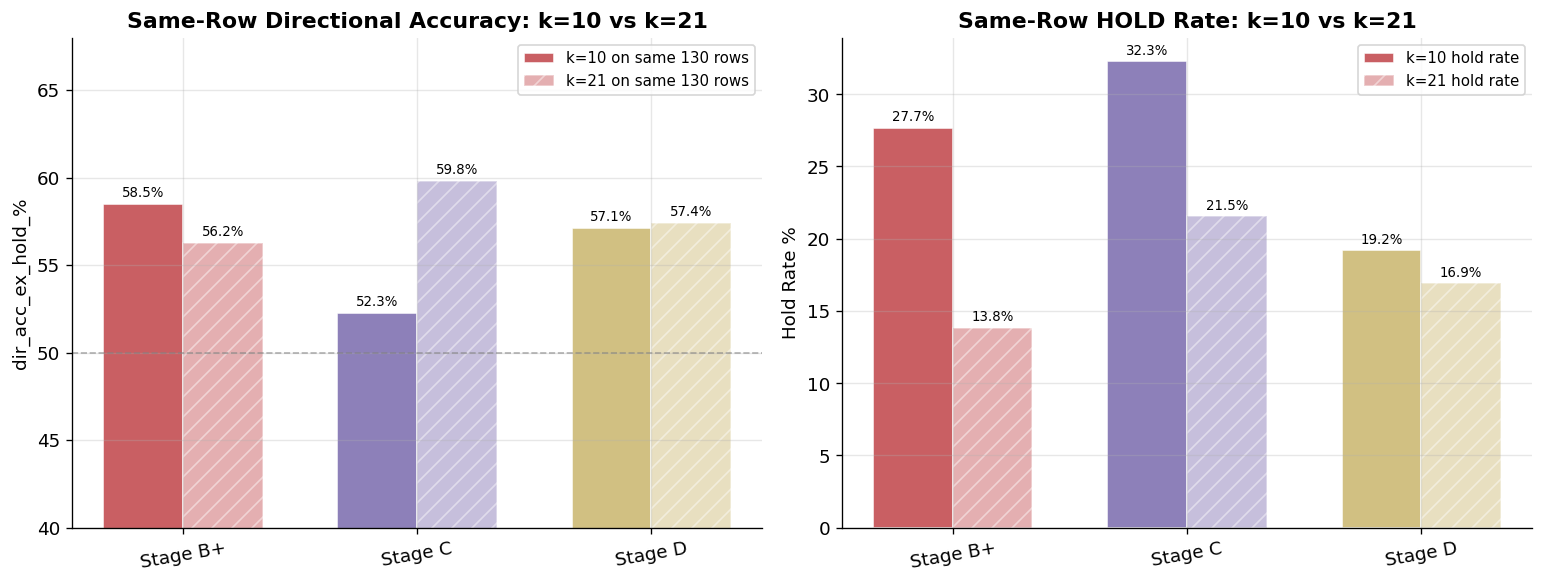

In [47]:
# ── Same-row horizon test: compare k=10 vs k=21 on the exact same 130 rows ──
# This removes the 385-vs-130 sample-size mismatch from the earlier horizon chart.

def metrics_from_scored_like_df(df, epsilon):
    commit = df[df["action"] != "HOLD"]
    hold   = df[df["action"] == "HOLD"]
    return {
        "dir_acc_%": commit["score"].mean() * 100 if len(commit) else float("nan"),
        "dir_n": len(commit),
        "hold_rate_%": len(hold) / len(df) * 100 if len(df) else float("nan"),
        "hold_acc_%": hold["score"].mean() * 100 if len(hold) else float("nan"),
    }

keys_21d = scored_csv_21d["Stage C (21d)"][["ticker", "simulated_date"]].drop_duplicates()

stage_name_map = {
    "Stage B+": "Stage B+ (21d)",
    "Stage C":  "Stage C (21d)",
    "Stage D":  "Stage D (21d)",
}

matched_horizon_rows = []
for stage_k10, stage_k21 in stage_name_map.items():
    k10_subset = agent_dfs[stage_k10].merge(keys_21d, on=["ticker", "simulated_date"], how="inner")
    k10_subset = k10_subset.rename(columns={"correct": "score"})
    k21_subset = scored_csv_21d[stage_k21].copy()

    m10 = metrics_from_scored_like_df(k10_subset, epsilon=HOLD_EPSILON_BASE)
    m21 = metrics_from_scored_like_df(k21_subset, epsilon=EPSILON_21D)

    matched_horizon_rows.append({
        "stage": stage_k10,
        "k10_dir_acc_%": m10["dir_acc_%"],
        "k21_dir_acc_%": m21["dir_acc_%"],
        "k10_hold_rate_%": m10["hold_rate_%"],
        "k21_hold_rate_%": m21["hold_rate_%"],
        "k10_hold_acc_%": m10["hold_acc_%"],
        "k21_hold_acc_%": m21["hold_acc_%"],
        "k10_dir_n": m10["dir_n"],
        "k21_dir_n": m21["dir_n"],
    })

matched_horizon_df = pd.DataFrame(matched_horizon_rows).set_index("stage").round(2)
print("=== Same 130 Rows: k=10 vs k=21 Comparison ===")
display(matched_horizon_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(matched_horizon_df)); w = 0.34
colors_match = [STAGE_COLORS[s] for s in matched_horizon_df.index]

ax1 = axes[0]
b1 = ax1.bar(x - w/2, matched_horizon_df["k10_dir_acc_%"], width=w, color=colors_match, alpha=0.9, edgecolor="white", label="k=10 on same 130 rows")
b2 = ax1.bar(x + w/2, matched_horizon_df["k21_dir_acc_%"], width=w, color=colors_match, alpha=0.45, hatch="//", edgecolor="white", label="k=21 on same 130 rows")
ax1.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
for bars_, vals_ in [(b1, matched_horizon_df["k10_dir_acc_%"]), (b2, matched_horizon_df["k21_dir_acc_%"] )]:
    for bar, v in zip(bars_, vals_):
        ax1.text(bar.get_x() + bar.get_width()/2, v + 0.25, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(matched_horizon_df.index, rotation=10)
ax1.set_ylim(40, 68)
ax1.set_ylabel("dir_acc_ex_hold_%")
ax1.set_title("Same-Row Directional Accuracy: k=10 vs k=21", fontweight="bold")
ax1.legend(fontsize=9)

ax2 = axes[1]
b3 = ax2.bar(x - w/2, matched_horizon_df["k10_hold_rate_%"], width=w, color=colors_match, alpha=0.9, edgecolor="white", label="k=10 hold rate")
b4 = ax2.bar(x + w/2, matched_horizon_df["k21_hold_rate_%"], width=w, color=colors_match, alpha=0.45, hatch="//", edgecolor="white", label="k=21 hold rate")
for bars_, vals_ in [(b3, matched_horizon_df["k10_hold_rate_%"]), (b4, matched_horizon_df["k21_hold_rate_%"] )]:
    for bar, v in zip(bars_, vals_):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.25, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(matched_horizon_df.index, rotation=10)
ax2.set_ylabel("Hold Rate %")
ax2.set_title("Same-Row HOLD Rate: k=10 vs k=21", fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CHART_DIR / "16_same130_k10_vs_k21.png", bbox_inches="tight")
plt.show()


In [48]:
# ── Interpretation helper: what the current 21-day evidence can and cannot claim ─
best_stage_21d = ci_21d["dir_acc_%"].idxmax()
pair_lookup = {row["pair"]: row for _, row in pairwise_21d.iterrows()}
bplus_vs_c = pair_lookup["Stage B+ (21d) vs Stage C (21d)"]
bplus_vs_d = pair_lookup["Stage B+ (21d) vs Stage D (21d)"]
c_vs_d = pair_lookup["Stage C (21d) vs Stage D (21d)"]

print("=== Interpretation Guide for the Current 21-Day Evidence ===\n")
print(f"Highest k=21 directional point estimate: {best_stage_21d} ({ci_21d.loc[best_stage_21d, 'dir_acc_%']:.2f}%)")
print("\nWhat is reasonably safe to claim:")
print("  1. Stage C is no longer a uniformly negative mechanism once the horizon is extended to 21 trading days.")
print("  2. The strongest new hypothesis is horizon sensitivity: the debate mechanism may need more time for the thesis to resolve.")
print("  3. The saved-score pairwise comparisons are close, so the current 130-row panel supports 'suggestive improvement', not 'decisive winner'.")

print("\nWhat the cleanest paired comparison says:")
print(f"  B+ vs D action agreement: {bplus_vs_d['action_agree_%']:.2f}%")
print(f"  Discordant row wins — B+: {bplus_vs_d['Stage B+ (21d)_only_correct']}, D: {bplus_vs_d['Stage D (21d)_only_correct']}")
print(f"  Exact sign-test p-value: {bplus_vs_d['overall_sign_p']:.4f}")
print("  Interpretation: memory does not show a convincing k=21 win on this panel; the clean paired evidence is weak / mixed.")

print("\nWhat the less-clean but still informative comparisons say:")
print(f"  B+ vs C discordant wins — B+: {bplus_vs_c['Stage B+ (21d)_only_correct']}, C: {bplus_vs_c['Stage C (21d)_only_correct']} | p={bplus_vs_c['overall_sign_p']:.4f}")
print(f"  C vs D discordant wins  — C: {c_vs_d['Stage C (21d)_only_correct']}, D: {c_vs_d['Stage D (21d)_only_correct']} | p={c_vs_d['overall_sign_p']:.4f}")
print("  Interpretation: Stage C has the best point estimate and slightly better row-level win pattern than D, but not by a margin large enough to dismiss LLM non-determinism.")

print("\nBest zero-cost next analyses:")
print("  • Use the same 130 rows from the frozen k=10 runs to compare horizon effects without the 385-vs-130 mismatch.")
print("  • Report uncertainty bands and pairwise discordant-win counts, not just raw percentages.")
print("  • Treat Stage C as a horizon-dependent result, not as a definitive replacement for B+.")

print("\nIf you can afford exactly one more expensive run:")
print("  • Repeat Stage C on the same 130 rows. That gives the highest value for estimating whether the new k=21 gain is stable or just one favorable sample.")


=== Interpretation Guide for the Current 21-Day Evidence ===

Highest k=21 directional point estimate: Stage C (21d) (59.80%)

What is reasonably safe to claim:
  1. Stage C is no longer a uniformly negative mechanism once the horizon is extended to 21 trading days.
  2. The strongest new hypothesis is horizon sensitivity: the debate mechanism may need more time for the thesis to resolve.
  3. The saved-score pairwise comparisons are close, so the current 130-row panel supports 'suggestive improvement', not 'decisive winner'.

What the cleanest paired comparison says:
  B+ vs D action agreement: 79.23%
  Discordant row wins — B+: 11.0, D: 7.0
  Exact sign-test p-value: 0.4807
  Interpretation: memory does not show a convincing k=21 win on this panel; the clean paired evidence is weak / mixed.

What the less-clean but still informative comparisons say:
  B+ vs C discordant wins — B+: 6.0, C: 5.0 | p=1.0000
  C vs D discordant wins  — C: 11.0, D: 8.0 | p=0.6476
  Interpretation: Stage C 